<a href="https://colab.research.google.com/github/ds-20195/notebooks/blob/main/Notebook3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data and the State (DATA 20195/30195)
# Lab 3: Managing Geographies

<font color=red> After running the first cell to install packages, you must restart the runtime so that `maup` and the interactive maps work properly. To do so, click on the dropdown next to "Run all" in the menu bar and then select "Restart session."</font>

In the last two labs, we've examined tabular data from the PL and ACS. That data is associated with geographic units — this week we will put it on the map. We'll explore how to download and visualize Census geographies, and we'll combine demographic data with these geographies to create [choropleth maps](https://en.wikipedia.org/wiki/Choropleth_map). We'll also introduce the **Modifiable Areal Unit Problem (MAUP)**, and introduce the `maup` package to transfer data from one set of units to another.

In [1]:
!pip install -q census us folium geopandas colorcet maup mapclassify

In [ ]:
# FILL THIS IN WITH YOUR OWN CENSUS API KEY. You can get one for free at https://api.census.gov/data/key_signup.html
api_key = "" # You have to fill this in with your own Census API key

In [ ]:
%config InlineBackend.figure_formats = ["retina"]

import matplotlib.pyplot as plt
import colorcet as cc # for some nice color maps

import pandas as pd
import numpy as np
import geopandas as gpd
import folium
import maup

from census import Census

state_fips  = "17"    # Illinois
county_fips = "031"   # Cook County
state_name  = "Illinois"
county_name = "Cook County"

In [ ]:
# @markdown This cell adds in a patch to the `census` package to fix an error caused by a change in the Census API.
# The bit of logic below this is to fix an error caused by the Census changing it's API
# requirement on 12 May 2026. The Census package did not properly pass the API key to all
# requests, so we have to patch the element that handles that logic.
from functools import lru_cache
from census.core import Client

def _patched_field_type(self, field, year):
    url = self.definition_url % (year, self.dataset, field)
    resp = self.session.get(url, params={"key": self._key})

    type_map = {
        "fips-for": str,
        "fips-in": str,
        "int": float,
        "long": float,
        "float": float,
        "string": str,
    }
    if resp.status_code == 200:
        try:
            predicate_type = resp.json().get("predicateType", "string")
            return type_map.get(predicate_type, str)
        except Exception:
            return str
    return str


# Apply lru_cache and patch onto the base class
Client._field_type = lru_cache(maxsize=1024)(_patched_field_type)

In [ ]:
if api_key == "":
    raise ValueError("You need to provide a Census API key to run this code. You can get one for free at https://api.census.gov/data/key_signup.html")

census = Census(key=api_key, year=2020)

In [3]:
# @markdown This code cell checks that the census API is working
try:
    county_populations = census.pl.get(
        ("NAME"),
        geo={"for": "state:17"}
    )
    print("The Census API appears to be working!")
except Exception:
    raise RuntimeError(
        "Error fetching data from the Census API. "
        "Please try disconnecting and reconnecting the runtime. "
        "If the problem persists after 2 resets, you will need to use our backup data cells to "
        "complete the lab"
    )

The Census API appears to be working!


## Loading geographical data

Census geographies are published as _shapefiles_. The [shapefile](https://en.wikipedia.org/wiki/Shapefile) is a clunky format developed by a company called ESRI for GIS (geographic information systems) practitioners, paired with their mapping tool [ArcGIS](https://www.arcgis.com/index.html) and also readable by the open-source alternative QGIS and most other mapping software. [GeoPandas](https://geopandas.org/en/stable/getting_started/introduction.html) is a Python package that extends Pandas to support reading shapefiles and plotting geographies; we'll use this package extensively in the coming weeks to build geospatial visualizations. Let's start opening the shapefile containing the outlines of all U.S. counties that we downloaded from the Census website.

In [4]:
county_gdf = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2024/COUNTY/tl_2024_us_county.zip").set_index("GEOID")
county_gdf.head(5)

,STATEFP,COUNTYFP,COUNTYNS,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
GEOID,,,,,,,,,,,,,,,,,,
31039,31,039,00835841,0500000US31039,Cuming,Cuming County,06,H1,G4020,None,None,None,A,1477563042,10772508,+41.9158651,-096.7885168,"POLYGON ((-96.55525 41.82892, -96.55524 41.827..."
53069,53,069,01513275,0500000US53069,Wahkiakum,Wahkiakum County,06,H1,G4020,None,None,None,A,680980773,61564428,+46.2946377,-123.4244583,"POLYGON ((-123.72755 46.2645, -123.72756 46.26..."
35011,35,011,00933054,0500000US35011,De Baca,De Baca County,06,H1,G4020,None,None,None,A,6016818941,29090018,+34.3592729,-104.3686961,"POLYGON ((-104.89337 34.08894, -104.89337 34.0..."
31109,31,109,00835876,0500000US31109,Lancaster,Lancaster County,06,H1,G4020,339,30700,None,A,2169269508,22850511,+40.7835474,-096.6886584,"POLYGON ((-96.68493 40.5233, -96.69219 40.5231..."
31129,31,129,00835886,0500000US31129,Nuckolls,Nuckolls County,06,H1,G4020,None,None,None,A,1489645201,1718484,+40.1764918,-098.0468422,"POLYGON ((-98.2737 40.1184, -98.27374 40.1224,..."


GeoPandas includes a `.plot()` function (similar to the `.plot.pie()` and `.plot.bar()` Pandas functions we saw in earlier labs). With this function, we can quickly get a sense of what `county_gdf` contains.

Note: the `figsize` parameter behaves unintuitively when working with geodataframes. For a deeper
explanation of what it does, please see [this link](https://github.com/ds-20195/notebooks/blob/main/supplemental_materials/geodataframe_figsize_and_aspect_explained.md).

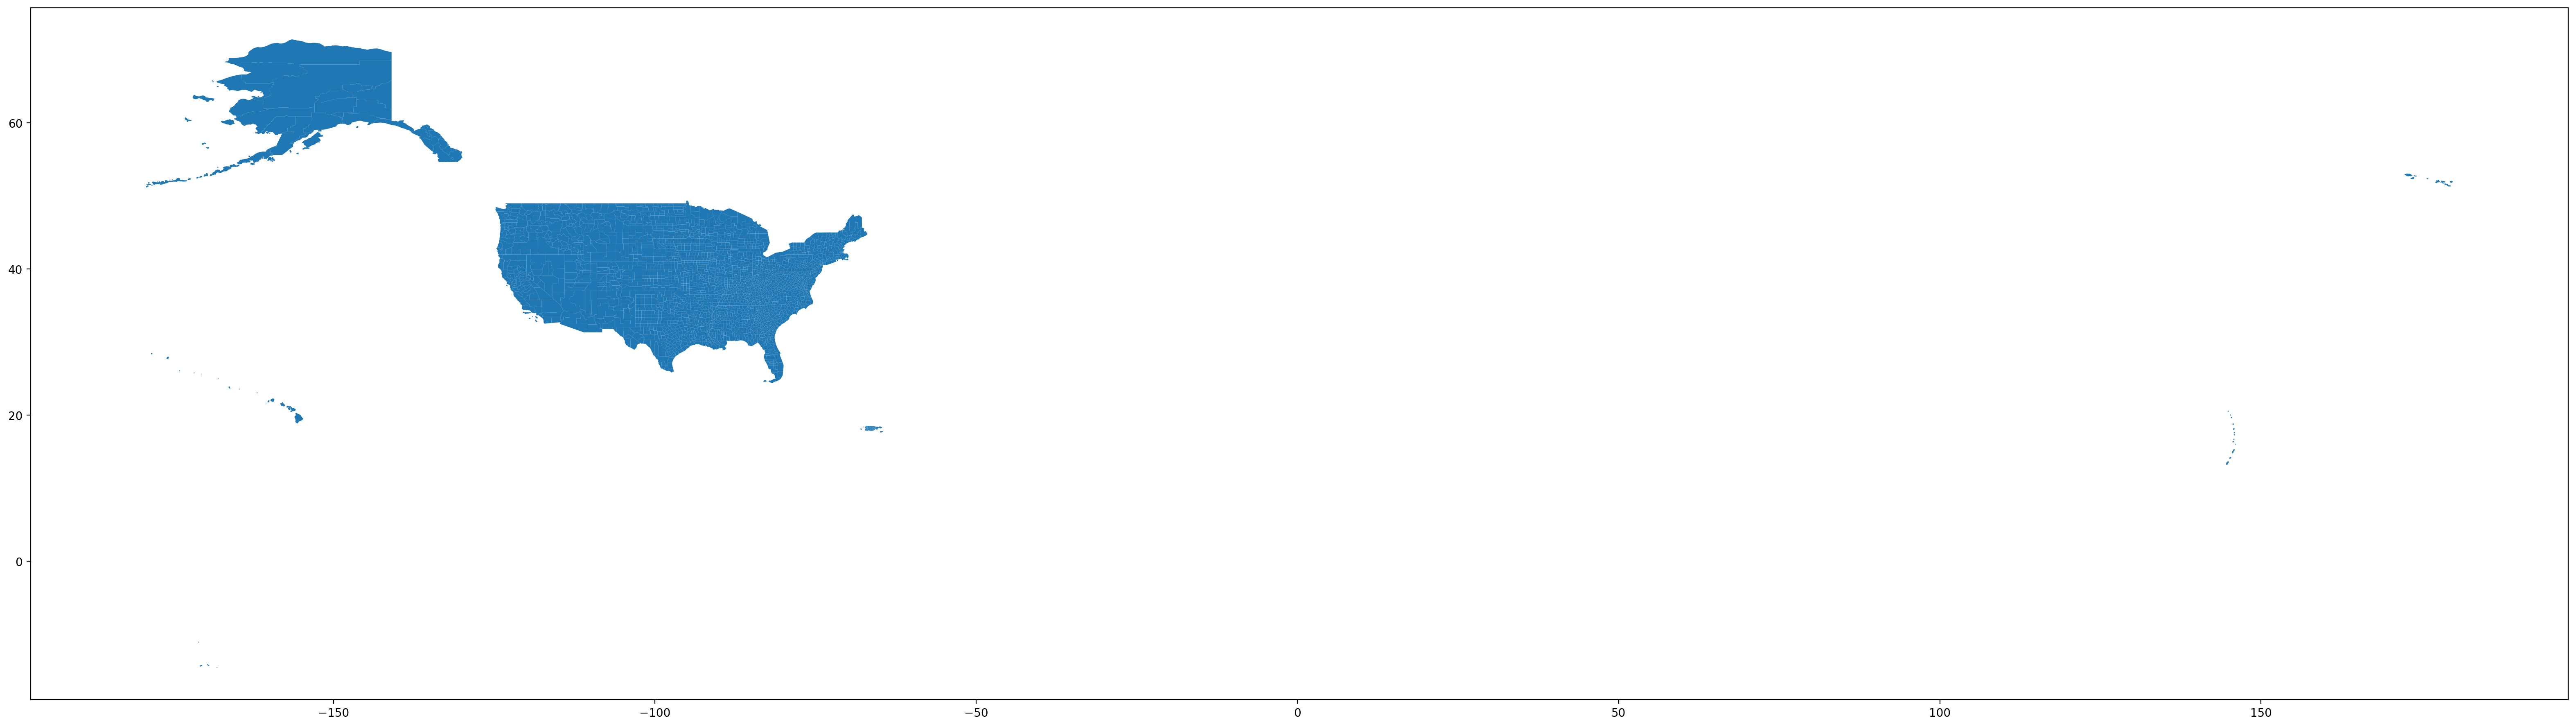

In [5]:
county_gdf.plot(figsize=(40, 80))
plt.show()

There's a problem with this initial visualization: it's mostly empty space! This is because the county shapefile covers _all_ territories of the U.S., including some Pacific territories (Guam, American Samoa, and the Northern Mariana Islands) that appear in the upper right of this plot. Let's narrow down the visualization to the continental U.S. by filtering on FIPS code (conveniently, the outlying territories all have FIPS codes above 56).

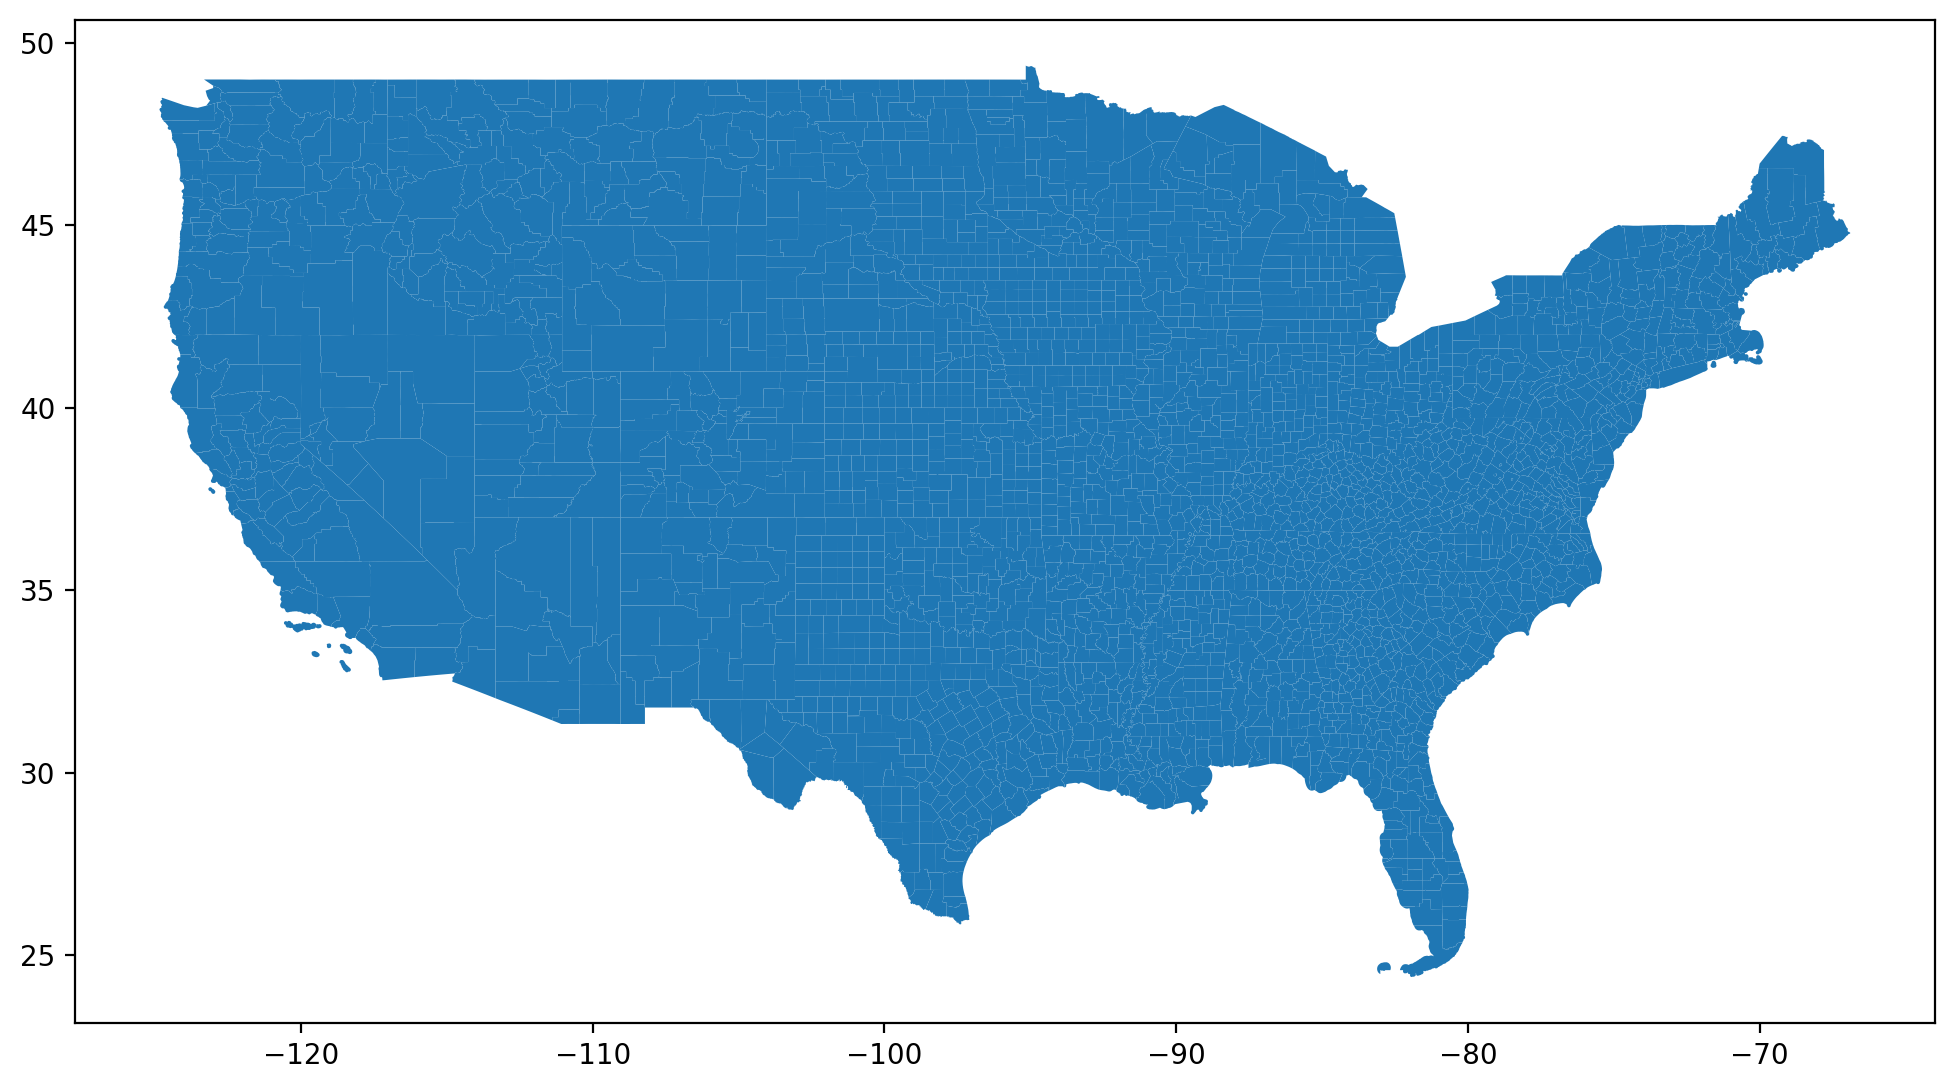

In [6]:
# Filter out American Samoa, U.S. Virgin Islands, etc. using a boolean mask
continental_gdf = county_gdf.loc[
      (county_gdf.STATEFP <= "56")
    & (county_gdf.STATEFP != "02")  # exclude Alaska
    & (county_gdf.STATEFP != "15")  # exclude Hawaii
]
continental_gdf.plot(figsize=(12, 24))
plt.show()

Now, let's color the map by state (using the `STATEFP` column, which contains the state FIPS code for each county). Note that some of the state borders look a little odd (this effect is most pronounced in Michigan); this is because the Census geographies include some water areas.

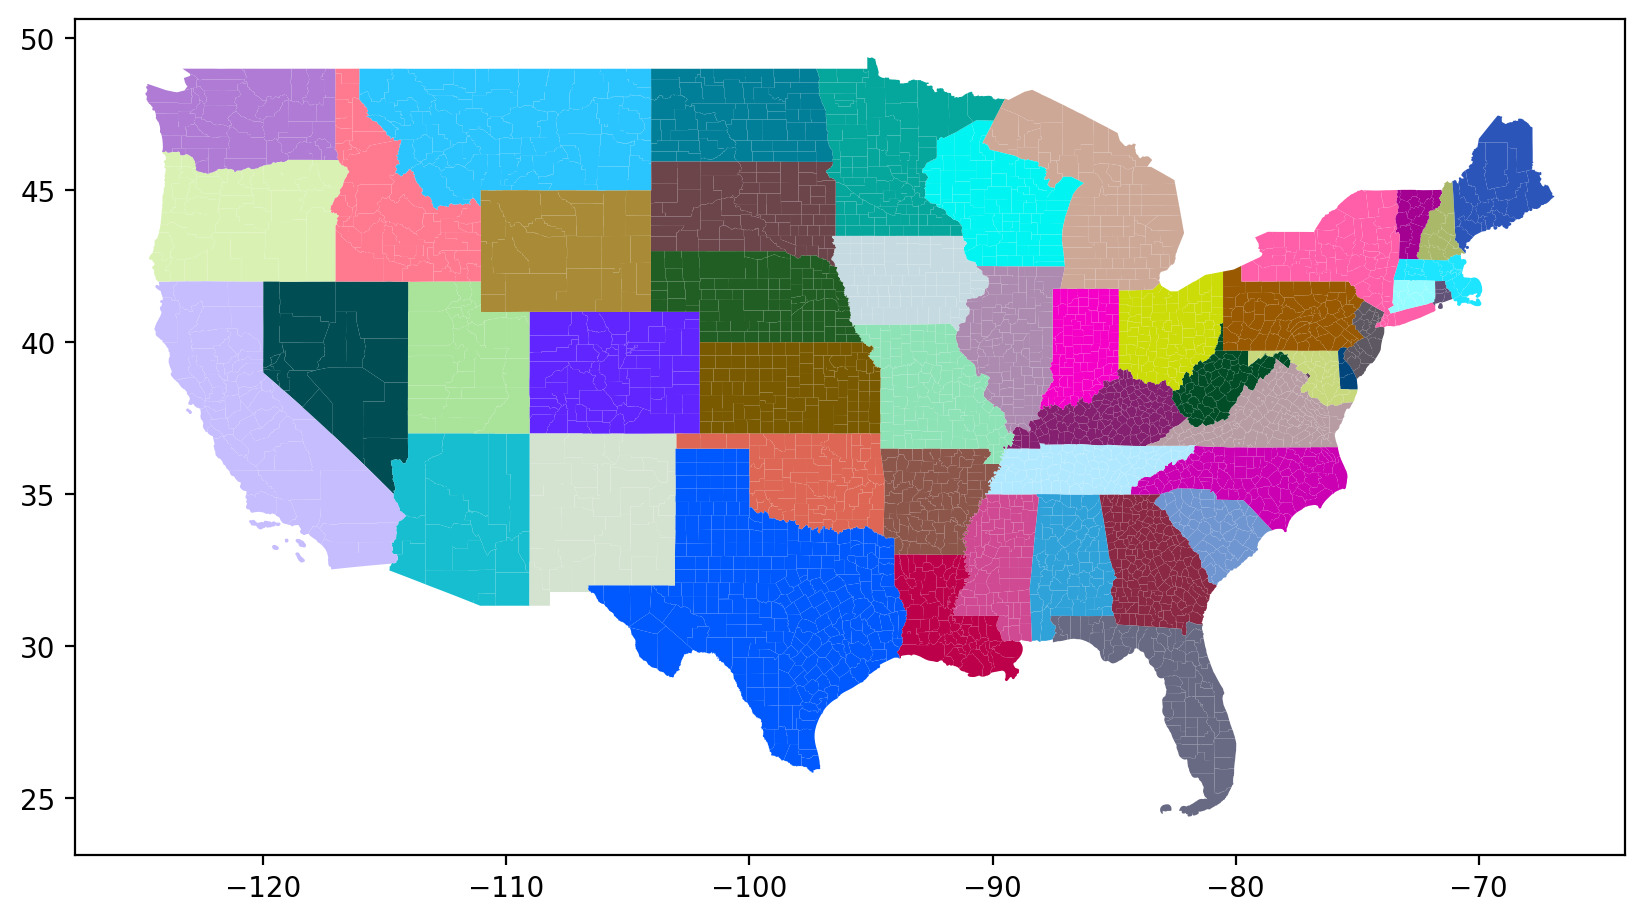

In [7]:
continental_gdf.plot(
    figsize=(10, 20),
    column="STATEFP",     # The column of the geodataframe to display on the plot
    cmap=cc.cm.glasbey_hv # A color map detailing how to display the data in the column
  )
plt.show()

#### TASK 1

Filter `continental_gdf` down to just Illinois counties (FIPS `"17"`) and plot the result. Use the `STATEFP` column.

In [8]:
# YOUR CODE HERE


# raise your hand and ask for help if you get stuck!

## Choosing a map projection

You may have noticed something off about the shape of the country in the above plot — that's because this plot is displayed in what the geographers call "unprojected coordinates," meaning that it uses latitude and longitude for its x and y coordinates directly, rather than transforming them to better represent either angles or areas. The standard Coordinate Reference System (CRS) that the Census tends to use for publishing its shapefiles is "NAD83" which we see below.

ref:
* [Choosing the right map projection](https://source.opennews.org/articles/choosing-right-map-projection/)
* [geopandas.GeoDataFrame.plot()](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html)

In [9]:
continental_gdf.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

We'll modify the CRS to "EPSG:2163" which is an equal-area geographic projection that should remove some of the distortion the next time
we plot the geometries.

In [10]:
continental_gdf = continental_gdf.to_crs("EPSG:2163")

continental_gdf.crs

<Projected CRS: EPSG:2163>
Name: US National Atlas Equal Area
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - onshore and offshore.
- bounds: (167.65, 15.56, -65.69, 74.71)
Coordinate Operation:
- name: US National Atlas Equal Area
- method: Lambert Azimuthal Equal Area (Spherical)
Datum: Not specified (based on Clarke 1866 Authalic Sphere)
- Ellipsoid: Clarke 1866 Authalic Sphere
- Prime Meridian: Greenwich

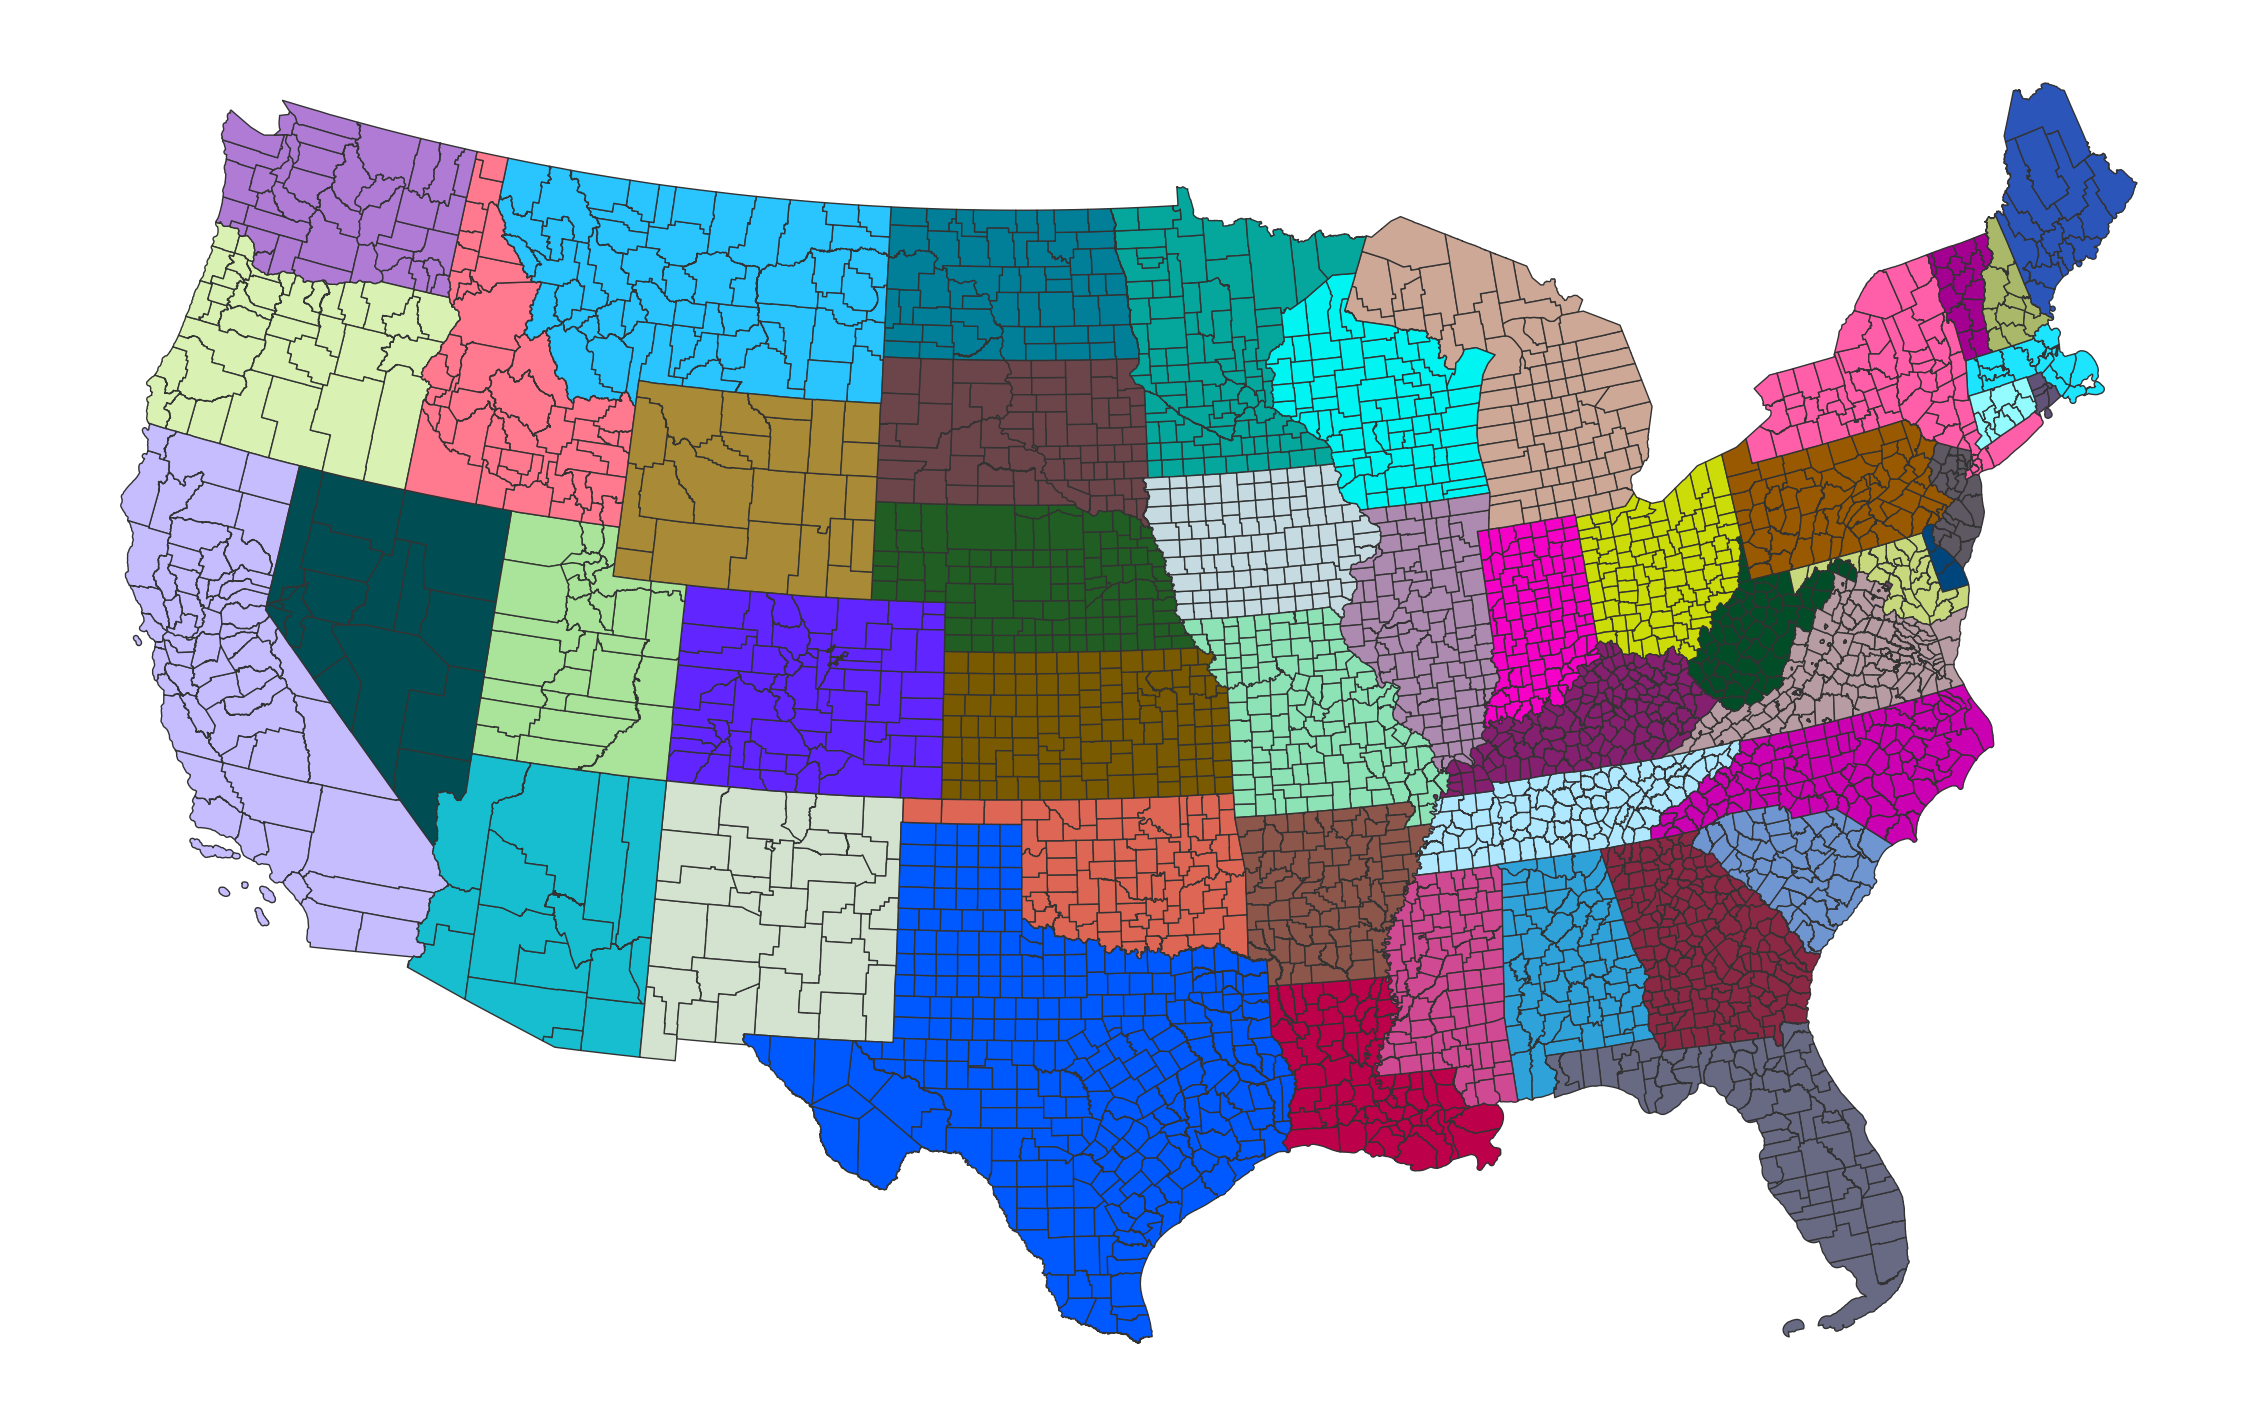

In [11]:
fig, ax = plt.subplots(figsize=(18,9))
continental_gdf.plot(
    ax=ax,
    column="STATEFP",
    cmap=cc.cm.glasbey_hv,
    edgecolor="0.2",
    linewidth=0.5,
)
ax.set_aspect('equal')
plt.axis("off")
plt.show()

## Visual comparison of geounits

### Counties
The U.S. Census releases a county shapefile at the national level which we have stored in `continental_gdf`; to plot just the counties in Illinois, we need to filter by state FIPS code.

In [12]:
il_county_gdf = continental_gdf.loc[continental_gdf.STATEFP == state_fips]
il_county_gdf.head(5)

,STATEFP,COUNTYFP,COUNTYNS,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
GEOID,,,,,,,,,,,,,,,,,,
17067,17,067,00424235,0500000US17067,Hancock,Hancock County,06,H1,G4020,None,None,None,A,2055798711,53563363,+40.4013180,-091.1688008,"POLYGON ((766989.767 -452305.185, 766989.56 -4..."
17025,17,025,00424214,0500000US17025,Clay,Clay County,06,H1,G4020,None,None,None,A,1213023041,3064499,+38.7468187,-088.4823254,"POLYGON ((976989.769 -619610.163, 976978.386 -..."
17185,17,185,00424293,0500000US17185,Wabash,Wabash County,06,H1,G4020,None,None,None,A,578403995,10973569,+38.4458209,-087.8391674,"POLYGON ((1054020.693 -669765.282, 1053948.636..."
17113,17,113,01784833,0500000US17113,McLean,McLean County,06,H1,G4020,145,14010,None,A,3064597289,7804856,+40.4945594,-088.8445391,"POLYGON ((937221.476 -461416.697, 937217.698 -..."
17005,17,005,00424204,0500000US17005,Bond,Bond County,06,H1,G4020,476,41180,None,A,985066646,6462629,+38.8859240,-089.4365916,"POLYGON ((920036.383 -636748.358, 919877.281 -..."


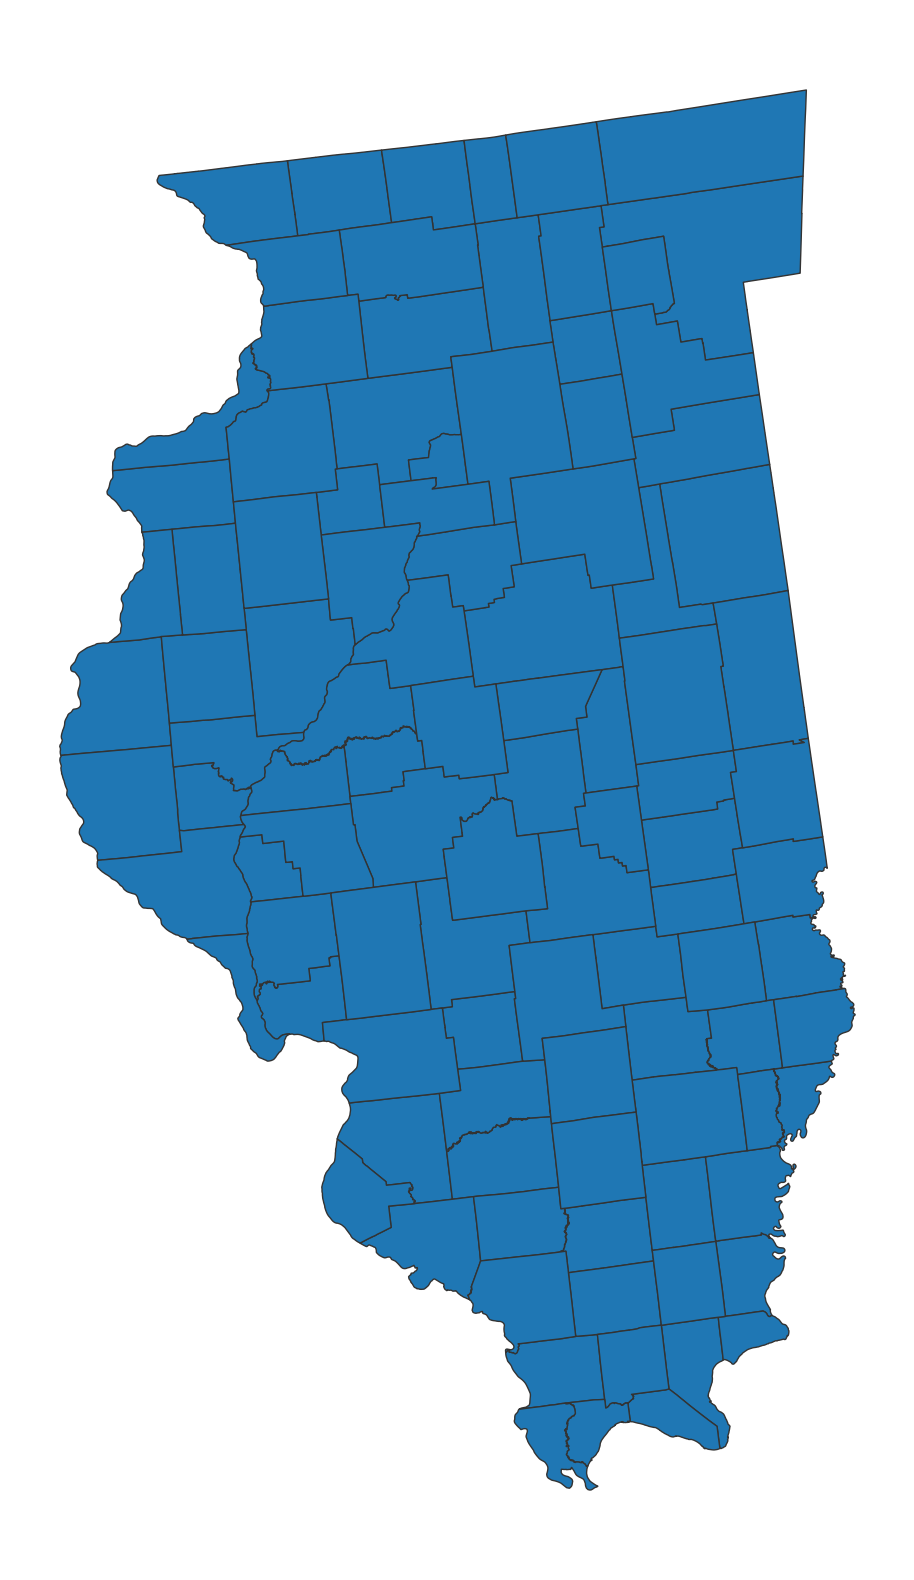

In [13]:
il_county_gdf.plot(
    figsize=(10, 10),
    edgecolor="0.2",
    linewidth=0.5
)
plt.axis("off")
plt.show()

### County subdivisions

For reporting purposes, the Census divides counties into _county subdivisions_. These subdivisions generally avoid dividing up preexisting political divisions: towns, cities, incorporated places, and the like. (For more on how county subdivisions are defined, see [chapter 8 of the _Geographic Areas Reference Manual_](https://www2.census.gov/geo/pdfs/reference/GARM/Ch8GARM.pdf).)  

As a rule of thumb, these are tilted toward equalizing area rather than population, so they look blocky on a map rather than getting tiny where the people are densest.

In [14]:
il_cousub_gdf = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2024/COUSUB/tl_2024_17_cousub.zip").set_index("GEOID").to_crs("EPSG:2163")
il_cousub_gdf.head(5)

,STATEFP,COUNTYFP,COUSUBFP,COUSUBNS,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
GEOID,,,,,,,,,,,,,,,,
1713945083,17,139,45083,00429288,0600000US1713945083,Lowe,Lowe township,44,T1,G4040,A,105167822,0,+39.7436650,-088.5299656,"POLYGON ((972256.573 -511756.739, 972446.75 -5..."
1703343315,17,033,43315,00429256,0600000US1703343315,Licking,Licking township,44,T1,G4040,A,105133097,33426,+39.1237278,-087.8944532,"POLYGON ((1035518.154 -572133.065, 1035694.128..."
1717306002,17,173,06002,00428674,0600000US1717306002,Big Spring,Big Spring township,44,T1,G4040,A,75999019,900218,+39.3113872,-088.5246712,"POLYGON ((979387.771 -562555.726, 979348.981 -..."
1717315417,17,173,15417,00428829,0600000US1717315417,Cold Spring,Cold Spring township,44,T1,G4040,A,90532402,35462,+39.3016790,-088.9646648,"POLYGON ((942149.271 -571689.05, 942150.133 -5..."
1717320851,17,173,20851,00428914,0600000US1717320851,Dry Point,Dry Point township,44,T1,G4040,A,62277983,0,+39.2454819,-088.8614171,"POLYGON ((952445.204 -578968.671, 952389.029 -..."


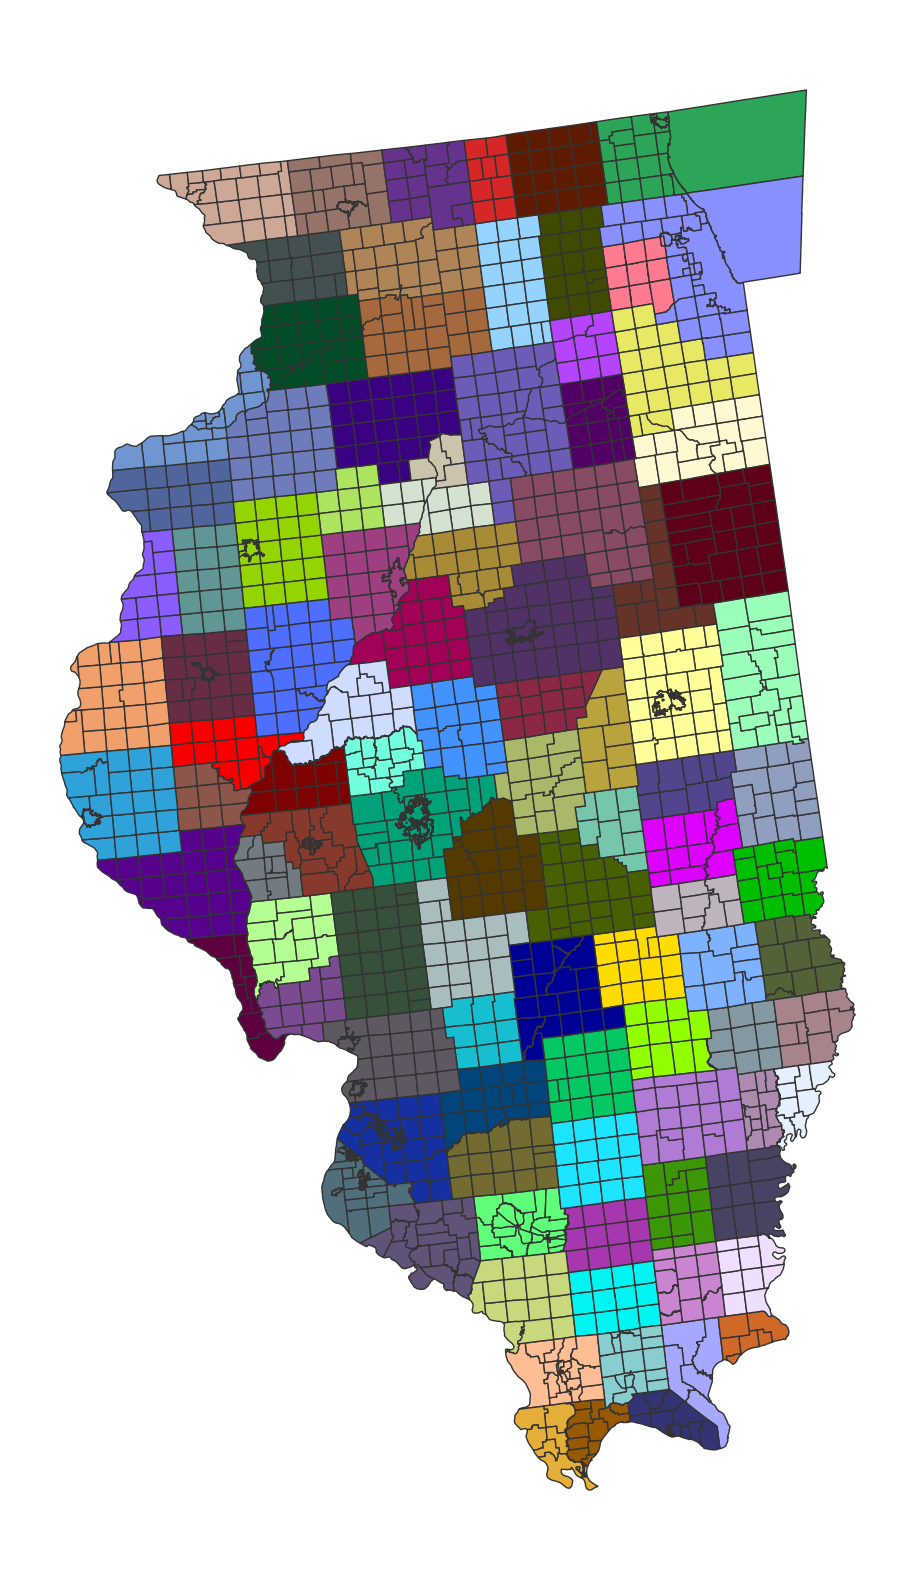

In [15]:
il_cousub_gdf.plot(
    figsize=(10, 10),
    column="COUNTYFP",
    cmap=cc.cm.glasbey_hv,
    edgecolor="0.2",
    linewidth=0.5
)
plt.axis("off")
plt.show()

### Tracts
Census tracts are immediately below counties on the central spine. While counties in Illinois (and most states) vary wildly in population, the populations of Census tracts are much more constrained: [according to the U.S. Census](https://www.census.gov/programs-surveys/geography/about/glossary.html#par_textimage_13), "Census tracts generally have a population size between 1,200 and 8,000 people, with an optimum size of 4,000 people". Because of this uniformity, the density of Census tracts roughly corresponds to population density. In the map below, observe the high density of small tracts in Chicago and the low density of large tracts in the sparsely populated downstate regions.

In [16]:
il_tract_gdf = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2024/TRACT/tl_2024_17_tract.zip").set_index("GEOID").to_crs("EPSG:2163")
il_tract_gdf.head(5)

,STATEFP,COUNTYFP,TRACTCE,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
GEOID,,,,,,,,,,,,,
17161022800,17,161,022800,1400000US17161022800,228,Census Tract 228,G5020,S,2103943,0,+41.4991066,-090.5472913,"POLYGON ((784683.519 -344627.615, 784682.039 -..."
17161022900,17,161,022900,1400000US17161022900,229,Census Tract 229,G5020,S,1311568,0,+41.4897868,-090.5477824,"POLYGON ((784689.739 -344734.362, 784693.173 -..."
17161023000,17,161,023000,1400000US17161023000,230,Census Tract 230,G5020,S,4680875,127822,+41.4757633,-090.5435406,"POLYGON ((785027.736 -348121.855, 785026.22 -3..."
17161023100,17,161,023100,1400000US17161023100,231,Census Tract 231,G5020,S,3496624,66115,+41.4684205,-090.5721252,"POLYGON ((782924.659 -347899.992, 782922.813 -..."
17019010902,17,019,010902,1400000US17019010902,109.02,Census Tract 109.02,G5020,S,329591263,290399,+39.9756592,-088.3626202,"POLYGON ((978901.635 -481271.118, 978937.876 -..."


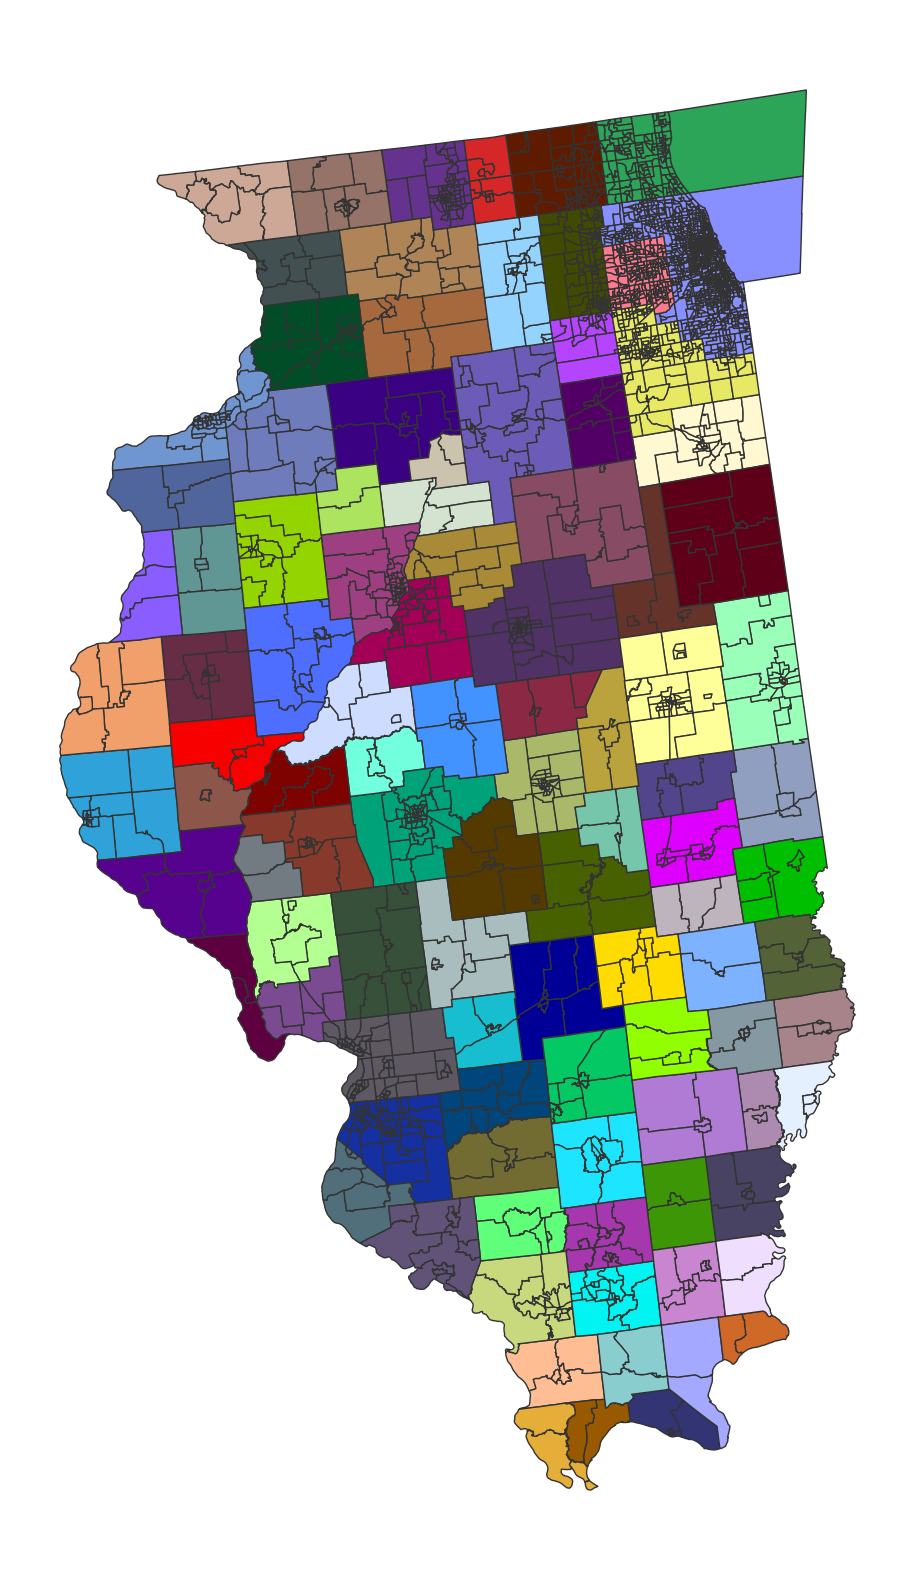

In [17]:
il_tract_gdf.plot(figsize=(10, 10), column="COUNTYFP", cmap=cc.cm.glasbey_hv, edgecolor="0.2", linewidth=0.5)
plt.axis("off")
plt.show()

We can filter by FIPS code to zoom in on a particular county. Here is Cook County, which contains Chicago and its inner suburbs.

In [18]:
cook_tract_gdf = il_tract_gdf[il_tract_gdf.COUNTYFP == county_fips]
cook_tract_gdf.head(5)

,STATEFP,COUNTYFP,TRACTCE,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
GEOID,,,,,,,,,,,,,
17031030101,17,031,030101,1400000US17031030101,301.01,Census Tract 301.01,G5020,S,127283,110999,+41.9910538,-087.6548790,"POLYGON ((1015369.985 -257809.801, 1015388.765..."
17031030701,17,031,030701,1400000US17031030701,307.01,Census Tract 307.01,G5020,S,69878,0,+41.9827453,-087.6579659,"POLYGON ((1015532.648 -258761.842, 1015551.415..."
17031070103,17,031,070103,1400000US17031070103,701.03,Census Tract 701.03,G5020,S,69094,0,+41.9268110,-087.6426051,"POLYGON ((1017727.833 -264692.94, 1017759.561 ..."
17031807100,17,031,807100,1400000US17031807100,8071,Census Tract 8071,G5020,S,1528033,0,+42.0444535,-087.7210786,"POLYGON ((1008693.403 -253337.488, 1008689.613..."
17031807200,17,031,807200,1400000US17031807200,8072,Census Tract 8072,G5020,S,2489125,0,+42.0371751,-087.7285103,"POLYGON ((1007614.261 -254317.897, 1007610.46 ..."


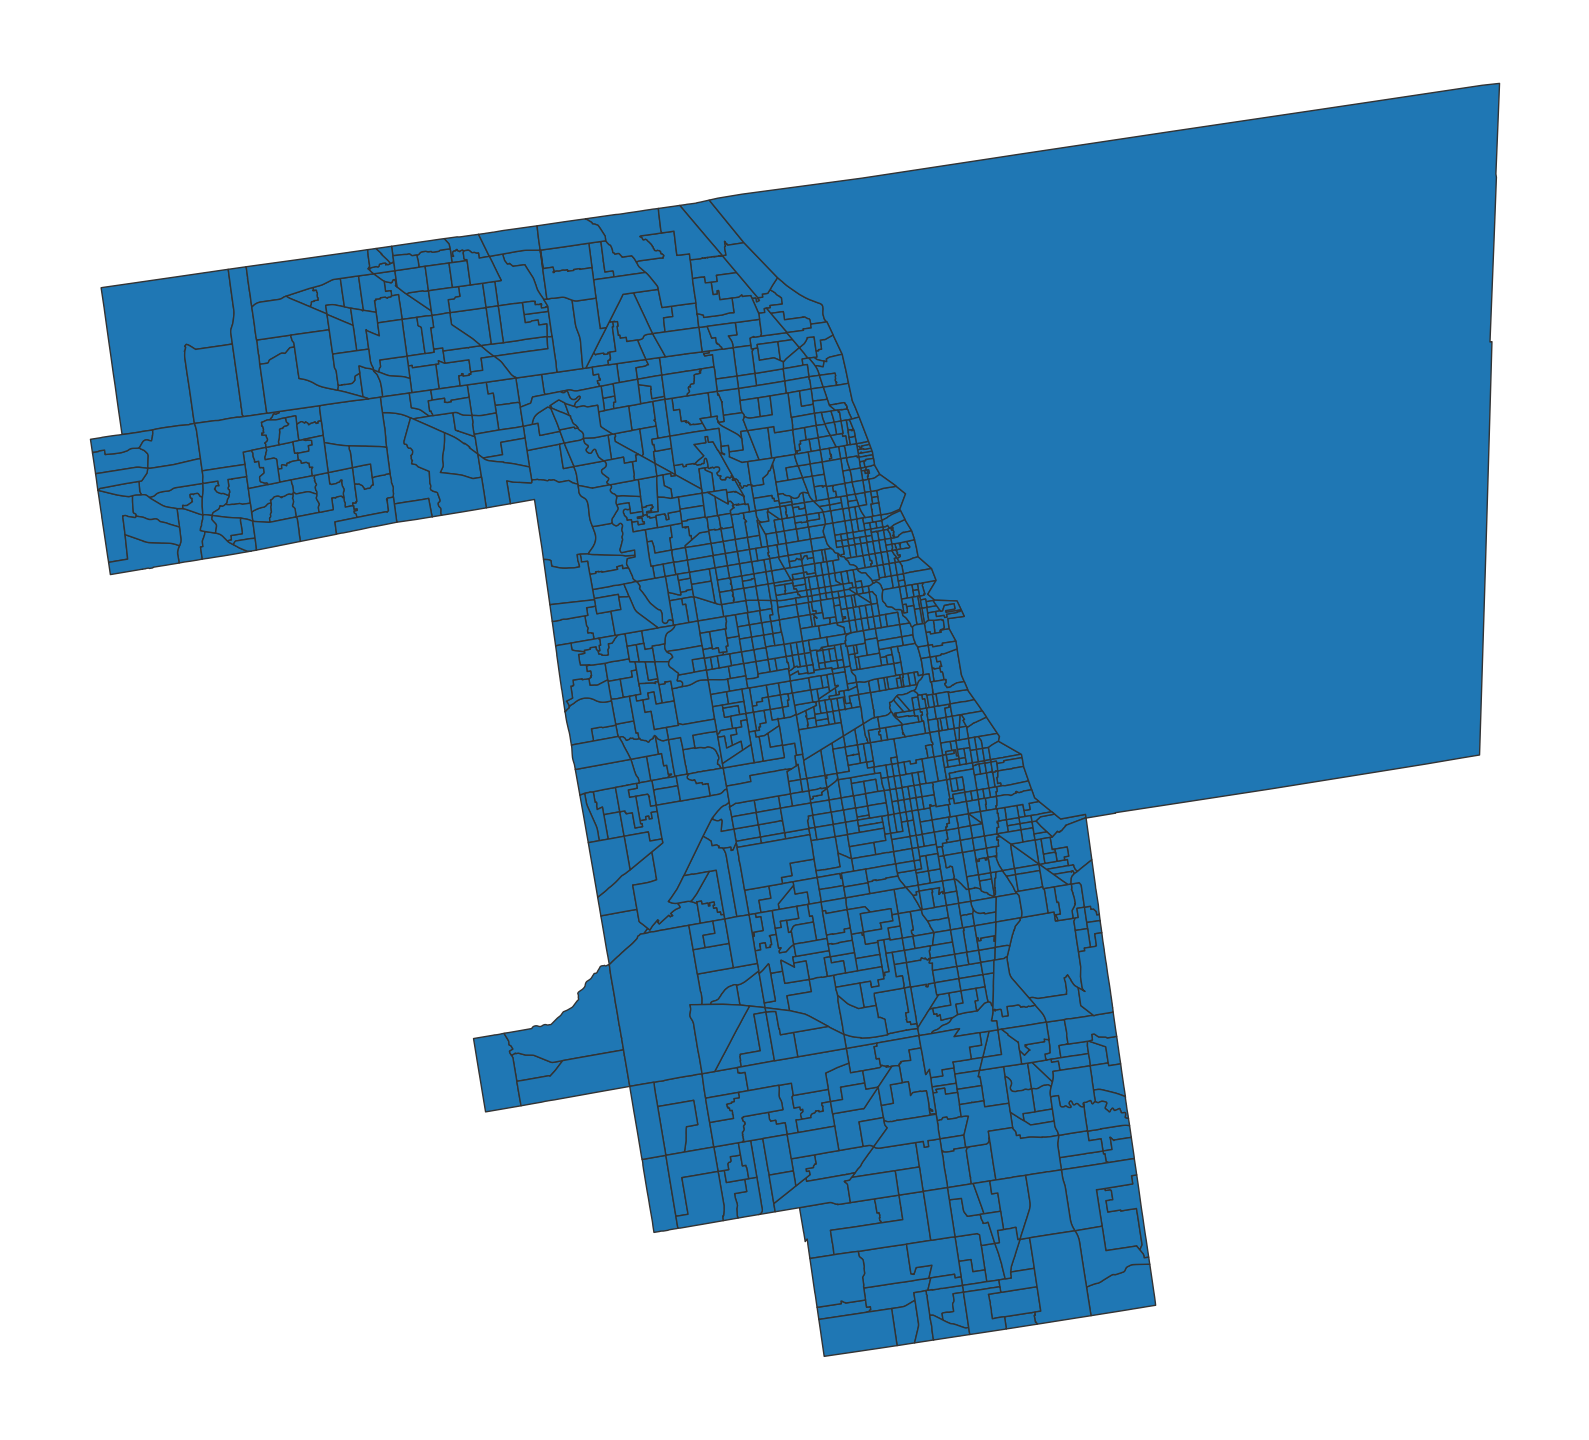

In [19]:
cook_tract_gdf.plot(figsize=(10, 10), edgecolor="0.2", linewidth=0.5)
plt.axis("off")
plt.show()

#### TASK 2

How many census tracts are in Cook County? How many county subdivisions are in Cook County? How many counties are in Illinois?

_Hint: use `len()` on the relevant GeoDataFrames._

In [20]:
# YOUR CODE HERE


# raise your hand and ask for help if you get stuck!

## Visualizing ACS data on geographies

Last week, we showed you how to retrieve data from the American Community Survey using the `census` package. Recall that the typical level of reporting for the ACS is tracts.

### DISCUSSION: ACS reporting resolution

Why is ACS data reported at the tract level as opposed to cousubs or blocks?

### Modes of transportation

We looked at some transit data in tabular form last time, and made plots to help visualize it.  Now we will map it.

In [21]:
means_of_transportation_variables = {
    "B08301_001E": "commuter_count",
    "B08301_010E": "transit_commuter_count",
}

In [22]:
# @markdown This code cell downloads the ACS data on means of transportation
# @markdown to work for all census tracts in Cook County, Illinois. It then
# @markdown processes and stores the data in `cook_transit_acs_df`.
cook_transit_raw = census.acs5.get(
    list(means_of_transportation_variables.keys()),
    geo={
        "for": "tract:*",
        "in": f"state:{state_fips} county:{county_fips}",
    },
    year=2023,
)

cook_transit_acs_df = pd.DataFrame(cook_transit_raw).rename(
    columns=means_of_transportation_variables
)
cook_transit_acs_df["GEOID"] = (
    cook_transit_acs_df["state"]
    + cook_transit_acs_df["county"]
    + cook_transit_acs_df["tract"]
)
cook_transit_acs_df = cook_transit_acs_df.set_index("GEOID")
cook_transit_acs_df[["commuter_count","transit_commuter_count"]] = (
    cook_transit_acs_df[["commuter_count","transit_commuter_count"]].astype(float)
)
cook_transit_acs_df["transit_pct"] = (
    100 * cook_transit_acs_df["transit_commuter_count"] / cook_transit_acs_df["commuter_count"]
)

In [23]:
# # Backup cell in case the ACS request fails
# cook_transit_acs_df = pd.read_parquet("https://github.com/ds-20195/notebooks/raw/refs/heads/main/backup_data/Notebook3_cook_transit_acs_df.parquet")

In [24]:
cook_transit_acs_df.sort_values(by=["transit_pct"])

,commuter_count,transit_commuter_count,state,county,tract,transit_pct
GEOID,,,,,,
17031829000,207.0,0.0,17,031,829000,0.000000
17031829100,1393.0,0.0,17,031,829100,0.000000
17031560400,524.0,0.0,17,031,560400,0.000000
17031829401,335.0,0.0,17,031,829401,0.000000
17031804715,1983.0,0.0,17,031,804715,0.000000
...,...,...,...,...,...,...
17031400800,1053.0,612.0,17,031,400800,58.119658
17031381700,0.0,0.0,17,031,381700,NaN
17031980000,0.0,0.0,17,031,980000,NaN


Note that we indexed by `GEOID` so that we can join with our GeoDataFrame more easily.

In [25]:
# filter out tracts with no commuters (avoid division-by-zero artifacts)
cook_transit_acs_df = cook_transit_acs_df[cook_transit_acs_df.commuter_count > 0]

cook_transit_gdf = cook_tract_gdf.join(cook_transit_acs_df)

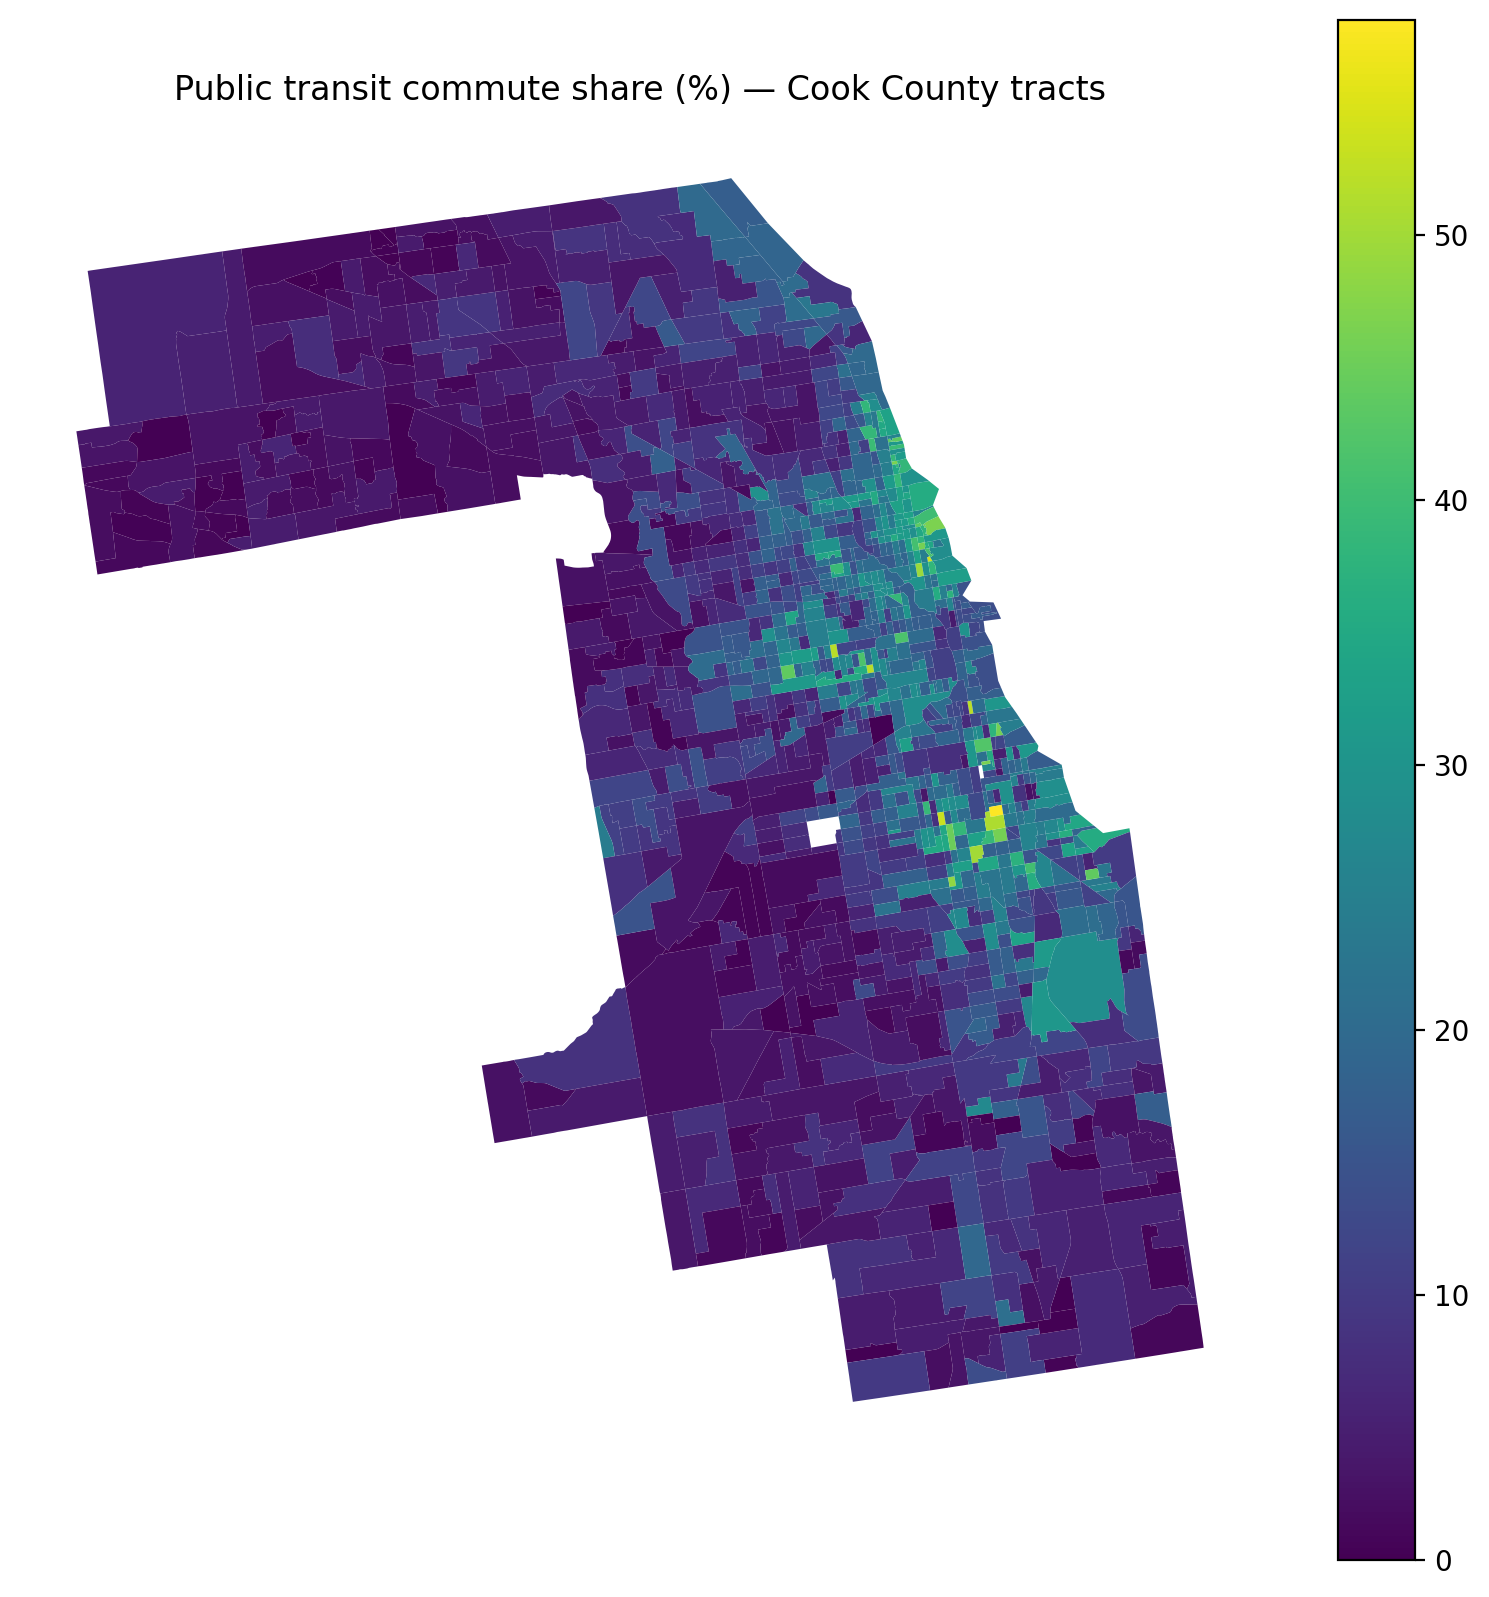

In [26]:
ax = cook_transit_gdf.plot(figsize=(10, 10), column="transit_pct", legend=True)
ax.axis("off")
ax.set_title(f"Public transit commute share (%) — {county_name} tracts")
plt.show()

We can also build an interactive version of this map using built-in GeoDataFrame `explore` method (built on top of [Folium](https://python-visualization.github.io/folium/latest/user_guide/map.html)), so you can pan, zoom, and hover over tracts.

In [27]:
# Backup -- straight folium version of shapes
# transit_map = folium.Map(
#     [41.85, -87.65],
#     zoom_start=10,
#     tiles="CartoDB positron"
# )
# folium.GeoJson(cook_transit_gdf.to_crs("EPSG:4326")).add_to(transit_map)
# transit_map

In [ ]:
# Note we need to convert to EPSG:4326 because we need latitude and longitude coodinates
transit_gdf = cook_transit_gdf.to_crs("EPSG:4326").copy()
transit_map = transit_gdf.explore(
    location=[41.85, -87.65],
    zoom_start=10,
    tiles="CartoDB positron"
)

transit_map

In [29]:
# # Backup -- straight folium version of choropleth
# transit_map = folium.Map(
#     [41.85, -87.65],
#     zoom_start=10,
#     tiles=None
# )

# # This is a quick work-around to get rid of some issues with colab and
# # the US hosted openstreetmap not cooperating with each other.
# folium.TileLayer(
#     tiles="https://tile.openstreetmap.de/{z}/{x}/{y}.png",
#     attr="OpenStreetMap"
# ).add_to(transit_map)


# folium.Choropleth(
#     geo_data=cook_transit_gdf.to_crs("EPSG:4326"),
#     name="choropleth",
#     data=cook_transit_acs_df["transit_pct"].dropna(),
#     key_on="feature.id",
#     fill_color="YlGn",
#     fill_opacity=0.7,
#     line_opacity=0.2,
#     legend_name="Public transit commute share (%)",
#     nan_fill_color="lightgrey",
# ).add_to(transit_map)
# transit_map

In [ ]:
transit_gdf["transit_pct"] = cook_transit_acs_df["transit_pct"]

transit_map = transit_gdf.explore(
    column="transit_pct",
    location=[41.85, -87.65],
    zoom_start=10,
    cmap="YlGn",
    legend=True,
    legend_kwds={"caption": "Public transit commute share (%)"},
    style_kwds={"weight": 0.2},
    missing_kwds={"color": "lightgrey"},

    # Change the values that appear when you hover your mouse over the geometries
    tooltip=["GEOID", "commuter_count", "transit_commuter_count", "transit_pct"],

    # The items below are a quick work-around to get rid of some issues with
    # colab and the US hosted openstreetmap not cooperating with each other.
    tiles="https://tile.openstreetmap.de/{z}/{x}/{y}.png",
    attr="OpenStreetMap",
)

transit_map

#### TASK 3

Use the `explore` method to make a Folium choropleth for a **different ACS variable** of your choice. Some ideas: median household income (`B19013_001E`), median age (`B01002_001E`), or percent of housing units that are renter-occupied (`B25003_003E` / `B25003_001E`).

You'll need to fetch the new variable, join it to `cook_tract_gdf`, and adapt the Folium code above.

References:
- ["ACS Detailed Table Shells"](https://www.census.gov/programs-surveys/acs/technical-documentation/table-shells.2023.html#list-tab-79594641)
- [Google sheets workbook](https://docs.google.com/spreadsheets/d/1DtGNarbQLaJdtMiINQ7brQ-Y6zawBkkBkp0VGSENsZw/edit?usp=sharing)

In [31]:
# YOUR CODE HERE

# raise your hand and ask for help if you get stuck!

# Elections: Measuring Turnout in Massachusetts

We're going to use the Data and Democracy Lab's "MAUP" package to transfer data between geounits.  You can read the docs [here](https://maup.readthedocs.io/en/latest/) if you're curious!

So far we've transferred data between **nested** geographies (blocks into tracts) using a simple `groupby`. But many important datasets use boundaries that don't nest into each other at all. **Election precinct** boundaries are drawn by local officials for administrative purposes — they freely cross tract and block group lines.  Sometimes they are even messy enough to cross census block lines, but we usually just treat them as equivalent with the best block-level approximation.


### A quick note on `df.apply`

Until now, when we have modified dataframe columns, we have done so through vector arithmetic operations (e.g., adding). In the next section, we will need to use the `apply` dataframe method because we'll be using what's effectively conditional logic, rather than simple arithmetic.

Succinctly, the syntax `df[col].apply(fn)` applies the function `fn` to each member of `col`. So

```python
# This cell is not executable

def subtract_if_positive(value):
    if value > 0:
        return value - 1
    else:
        return value

df['my_column'] = df['my_column'].apply(subtract_if_positive)
```

will do the same thing as

```python
# This cell is not executable

df['my_column'] = df['my_column'] - 1
```

when the values are positive, but will leave zero and negative values unchanged.

## Preparing the data

Our goal is to take a look at **voter turnout** across Massachusetts — presidential votes cast as a share of adult citizens (CVAP). This requires:
1. Precinct-level election results
2. Block-level voting age population (VAP), from the 2010 PL.
3. Tract-level citizen voting age population (CVAP) data from the ACS.
4. Using `maup.prorate` to chop the tract-level CVAP down to blocks, then aggregate back to precincts.

Important note!  We must mix data sources here because citizenship data is only in the ACS, but block-level population is only in the PL.

We will be using the 2012 General election data from MA in this notebook.
To get the shapefile for this project, we can pull from the
[Massachusetts GIS Website](https://www.mass.gov/info-details/massgis-data-layers) and download the appropriate file for working with 2012 data (`wardsprecincts_poly.zip`) for our geodataframe.

In [32]:
ma_ward_precinct_gdf = gpd.read_file("https://s3.us-east-1.amazonaws.com/download.massgis.digital.mass.gov/shapefiles/state/wardsprecincts_poly.zip")

Since the geometry is uniquely identified by the combination of the Town, Ward, and Precinct, we make a column called "Name" containing this information.

In [33]:
# @markdown This cell prepares the MA data and creates the "Name" column
ma_ward_precinct_gdf["TOWN"] = ma_ward_precinct_gdf["TOWN"].str.title()
ma_ward_precinct_gdf = ma_ward_precinct_gdf[["TOWN", "WARD", "PRECINCT", "DISTRICT", "geometry"]]
ma_ward_precinct_gdf.rename(columns={"DISTRICT": "VTD"}, inplace=True)

# we use string concatenation to make the "Name" column
ma_ward_precinct_gdf["Name"] = (
    ma_ward_precinct_gdf["TOWN"] +
    " Ward " + ma_ward_precinct_gdf["WARD"].astype(str) +
    " Precinct " + ma_ward_precinct_gdf["PRECINCT"].astype(str)
)
ma_ward_precinct_gdf

,TOWN,WARD,PRECINCT,VTD,geometry,Name
0,Braintree,None,5B,5B,"POLYGON ((242364.517 883741.979, 242359.642 88...",Braintree Ward None Precinct 5B
1,Braintree,None,6A,6A,"POLYGON ((243479.798 881994.897, 243477.538 88...",Braintree Ward None Precinct 6A
2,Braintree,None,6B,6B,"POLYGON ((241614.364 881551.551, 241602.936 88...",Braintree Ward None Precinct 6B
3,Chelsea,1,1,1-1,"POLYGON ((239281.036 904133.287, 239277.513 90...",Chelsea Ward 1 Precinct 1
4,Chelsea,1,2,1-2,"POLYGON ((238408.578 904480.138, 238393.14 904...",Chelsea Ward 1 Precinct 2
...,...,...,...,...,...,...
2147,Boston,7,8,7-8,"POLYGON ((236328.257 897806.825, 236339.793 89...",Boston Ward 7 Precinct 8
2148,Boston,12,3,12-3,"POLYGON ((234387.165 896770.015, 234357.873 89...",Boston Ward 12 Precinct 3
2149,Boston,12,2,12-2,"POLYGON ((234109.165 896499.623, 234101.151 89...",Boston Ward 12 Precinct 2
2150,Boston,11,2,11-2,"POLYGON ((233908.714 896981.859, 233743.883 89...",Boston Ward 11 Precinct 2


Now we retrieve the election data. You can find this at the
[Massachusetts Election Data Page](https://electionstats.state.ma.us/elections/).

In [34]:
ma_elec_12_df = pd.read_csv("https://electionstats.state.ma.us/elections/download/112698/precincts_include:1/")
ma_elec_12_df

,City/Town,Ward,Pct,Obama/ Biden,Romney/ Ryan,Johnson/ Gray,Stein/ Honkala,All Others,Blanks,Total Votes Cast
0,NaN,NaN,NaN,Democratic,Republican,Libertarian,Green-Rainbow,NaN,NaN,NaN
1,Abington,-,1,844,705,6,7,4,5,"1,571"
2,Abington,-,2,742,741,18,8,4,7,"1,520"
3,Abington,-,3,815,801,13,11,2,6,"1,648"
4,Abington,-,4,899,904,8,9,5,5,"1,830"
...,...,...,...,...,...,...,...,...,...,...
2171,Yarmouth,-,4,"1,056",909,10,9,2,15,"2,001"
2172,Yarmouth,-,5,882,810,11,8,0,8,"1,719"
2173,Yarmouth,-,6,924,826,13,11,2,7,"1,783"
2174,Yarmouth,-,7,"1,169","1,269",13,11,1,6,"2,469"


Unfortunately, the election data retrieved from the state's website does not readily align with the state's shapefile: there are 2176 rows in the election file but only 2152 in the shapefile.



### DISCUSSION: Misaligned data

Use the code cell below to explore the dataframes and see where they differ.

- What are some differences that you observe?
- At some point, we will want to join these dataframes together; what columns can we use to construct a meaningful index for the join?

In [35]:
# YOUR CODE HERE

We need to rectify this misalignment so that we may join our dataframes together. We will do this by some light language processing.


First, we drop the rows that do not correspond to vote data.

In [36]:
if ma_elec_12_df.shape[0] == 2176:
    ma_elec_12_df = ma_elec_12_df.drop([0, 2175])

ma_elec_12_df = ma_elec_12_df.reset_index(drop=True)

Second, we clean the vote tally data and ensure that the tallies are numeric as opposed to strings.

In [37]:
columns_to_convert = [
    "Obama/ Biden", "Romney/ Ryan", "Johnson/ Gray",
    "Stein/ Honkala", "All Others", "Blanks", "No Preference", "Total Votes Cast"
]

# We create a function that takes dataframe column values which might be strings
# of the form "10,000" and converts them to integers
def parse_string_as_integer(value):
    # Check if the value is a string
    if isinstance(value, str):
        # remove The comma and then call the int function to convert (cast)
        # the string to an int
        return int(value.replace(",", ""))
    return int(value)

for col in columns_to_convert:
    # This if statement allows this cell to be re-run without issues
    if col in ma_elec_12_df.columns:
        ma_elec_12_df[col] = ma_elec_12_df[col].apply(
            parse_string_as_integer
        )

Lastly, we construct a good index column so that joining tables is easy later.

In [38]:
def clean_ward_name(raw_name):
    if raw_name == "-":
        return "None"
    else:
        return raw_name

new_col = []
ma_elec_12_df["Ward"] = ma_elec_12_df["Ward"].apply(clean_ward_name)

ma_elec_12_df["Name"] = (
    ma_elec_12_df["City/Town"]
    + " Ward " + ma_elec_12_df["Ward"]
    + " Precinct " + ma_elec_12_df["Pct"].astype(str)
)
ma_elec_12_df

,City/Town,Ward,Pct,Obama/ Biden,Romney/ Ryan,Johnson/ Gray,Stein/ Honkala,All Others,Blanks,Total Votes Cast,Name
0,Abington,None,1,844,705,6,7,4,5,1571,Abington Ward None Precinct 1
1,Abington,None,2,742,741,18,8,4,7,1520,Abington Ward None Precinct 2
2,Abington,None,3,815,801,13,11,2,6,1648,Abington Ward None Precinct 3
3,Abington,None,4,899,904,8,9,5,5,1830,Abington Ward None Precinct 4
4,Abington,None,5,844,910,8,2,5,5,1774,Abington Ward None Precinct 5
...,...,...,...,...,...,...,...,...,...,...,...
2169,Yarmouth,None,3,860,694,11,13,5,8,1591,Yarmouth Ward None Precinct 3
2170,Yarmouth,None,4,1056,909,10,9,2,15,2001,Yarmouth Ward None Precinct 4
2171,Yarmouth,None,5,882,810,11,8,0,8,1719,Yarmouth Ward None Precinct 5
2172,Yarmouth,None,6,924,826,13,11,2,7,1783,Yarmouth Ward None Precinct 6


The election dataframe still contains 2174 rows compared to the 2152 in the shapefile. We have constructed the "Name" column to be comparable between these two dataframes, but they still don't fully align.

In [39]:
# Print out some of the names that are in the election data but not in the ward precinct data
sorted(set(ma_elec_12_df["Name"]) - set(ma_ward_precinct_gdf["Name"]))[:15]

['Andover Ward None Precinct 7A',
 'Andover Ward None Precinct 9A',
 'Bellingham Ward None Precinct 4A',
 'Cambridge Ward 3 Precinct 2A',
 'Chicopee Ward 6 Precinct AN',
 'Chicopee Ward 6 Precinct AS',
 'Chicopee Ward 6 Precinct BE',
 'Chicopee Ward 6 Precinct BW',
 'Dracut Ward None Precinct 6A',
 'E. Bridgewater Ward None Precinct 1',
 'E. Bridgewater Ward None Precinct 2',
 'E. Bridgewater Ward None Precinct 3',
 'E. Bridgewater Ward None Precinct 4',
 'E. Brookfield Ward None Precinct 1',
 'E. Longmeadow Ward None Precinct 1']

Now the reverse.

In [40]:
# Print out the some of names that are in the ward precinct data but not in the election data
sorted(set(ma_ward_precinct_gdf["Name"]) - set(ma_elec_12_df["Name"]))[:15]

['Chicopee Ward 6 Precinct A',
 'Chicopee Ward 6 Precinct B',
 'East Bridgewater Ward None Precinct 1',
 'East Bridgewater Ward None Precinct 2',
 'East Bridgewater Ward None Precinct 3',
 'East Bridgewater Ward None Precinct 4',
 'East Brookfield Ward None Precinct 1',
 'East Longmeadow Ward None Precinct 1',
 'East Longmeadow Ward None Precinct 2',
 'East Longmeadow Ward None Precinct 3',
 'East Longmeadow Ward None Precinct 4',
 'Manchester Ward None Precinct 1',
 'North Adams Ward 1 Precinct 1',
 'North Adams Ward 2 Precinct 2',
 'North Adams Ward 3 Precinct 3']

It's clear that E. corresponds to East, N. to North, and so on, so we replace these abbreviations.



In [41]:
def fix_city_town(x):
    if "E." in x:
        return x.replace("E. ", "East ")
    elif "W." in x:
        return x.replace("W. ", "West ")
    elif "N." in x:
        return x.replace("N. ", "North ")
    elif "S." in x:
        return x.replace("S. ", "South ")
    else:
        return x

ma_elec_12_df["City/Town"] = ma_elec_12_df["City/Town"].apply(fix_city_town)
ma_elec_12_df["Name"] = (
    ma_elec_12_df["City/Town"]
    + " Ward " + ma_elec_12_df["Ward"]
    + " Precinct " + ma_elec_12_df["Pct"].astype(str)
)
len(ma_elec_12_df["Name"].unique())

2174

What's left? Let's look at some set differences to see where the precinct lists still differ.

In [42]:
set(ma_elec_12_df.Name) - set(ma_ward_precinct_gdf.Name)

{'Andover Ward None Precinct 7A',
 'Andover Ward None Precinct 9A',
 'Bellingham Ward None Precinct 4A',
 'Cambridge Ward 3 Precinct 2A',
 'Chicopee Ward 6 Precinct AN',
 'Chicopee Ward 6 Precinct AS',
 'Chicopee Ward 6 Precinct BE',
 'Chicopee Ward 6 Precinct BW',
 'Dracut Ward None Precinct 6A',
 'Fall River Ward 5 Precinct B1',
 'Fall River Ward 6 Precinct C1',
 'Hingham Ward None Precinct 5A',
 'Manchester-by-the-Sea Ward None Precinct 1',
 'Newburyport Ward 1 Precinct P',
 'Palmer Ward None Precinct 1A',
 'Peabody Ward 4 Precinct 3A',
 'Quincy Ward 2 Precinct 3A',
 'Raynham Ward None Precinct 1A',
 'Raynham Ward None Precinct 2A',
 'Revere Ward 2 Precinct 3A',
 'Revere Ward 5 Precinct 1A',
 'Revere Ward 5 Precinct 2A',
 'Sudbury Ward None Precinct 1A',
 'Warren Ward None Precinct B',
 'Winchendon Ward None Precinct 1A'}

In [43]:
set(ma_ward_precinct_gdf.Name) - set(ma_elec_12_df.Name)

{'Chicopee Ward 6 Precinct A',
 'Chicopee Ward 6 Precinct B',
 'Manchester Ward None Precinct 1'}

At this point, it might be best to just hop on the phone and contact one of the election officials to ask how to accurately aggregate the data, but this is not always possible.  So we'll use our best judgment.  The next cell does some common-sense ad hoc fixes, like matching Andover 7A to Andover 7.

In [44]:
# @markdown This cell creates a function called `fix_name` that is then applied
# @markdown to `ma_elec_12_df["Name"]`

def fix_name(x):
    fix_dictionary = {
        'Andover Ward None Precinct 7A': "Andover Ward None Precinct 7",
        'Andover Ward None Precinct 9A': "Andover Ward None Precinct 9",
        'Bellingham Ward None Precinct 4A': "Bellingham Ward None Precinct 4",
        'Cambridge Ward 3 Precinct 2A': "Cambridge Ward 3 Precinct 2",
        'Chicopee Ward 6 Precinct AN': "Chicopee Ward 6 Precinct A",
        'Chicopee Ward 6 Precinct AS': "Chicopee Ward 6 Precinct A",
        'Chicopee Ward 6 Precinct BE': "Chicopee Ward 6 Precinct B",
        'Chicopee Ward 6 Precinct BW': "Chicopee Ward 6 Precinct B",
        'Dracut Ward None Precinct 6A': "Dracut Ward None Precinct 6",
        'Fall River Ward 5 Precinct B1': "Fall River Ward 5 Precinct B",
        'Fall River Ward 6 Precinct C1': "Fall River Ward 6 Precinct C",
        'Hingham Ward None Precinct 5A': "Hingham Ward None Precinct 5",
        'Manchester-by-the-Sea Ward None Precinct 1': "Manchester Ward None Precinct 1",
        'Palmer Ward None Precinct 1A': "Palmer Ward None Precinct 1",
        'Peabody Ward 4 Precinct 3A': "Peabody Ward 4 Precinct 3",
        'Quincy Ward 2 Precinct 3A': "Quincy Ward 2 Precinct 3",
        'Raynham Ward None Precinct 1A': "Raynham Ward None Precinct 1",
        'Raynham Ward None Precinct 2A': "Raynham Ward None Precinct 2",
        'Revere Ward 2 Precinct 3A': "Revere Ward 2 Precinct 3",
        'Revere Ward 5 Precinct 1A': "Revere Ward 5 Precinct 1",
        'Revere Ward 5 Precinct 2A': "Revere Ward 5 Precinct 2",
        'Sudbury Ward None Precinct 1A': "Sudbury Ward None Precinct 1",
        'Winchendon Ward None Precinct 1A': "Winchendon Ward None Precinct 1",

    }
    if x in fix_dictionary:
        return fix_dictionary[x]
    else:
        return x

ma_elec_12_df["Name"] = ma_elec_12_df["Name"].apply(fix_name)

print(f"There are {len(ma_elec_12_df['Name'].unique()) - 2152} ambiguous values remaining")

There are 2 ambiguous values remaining


Two ambiguous cases remain, and their mismatched identities can be resolved with a little more sleuthing.

In [45]:
def fix_name_part2(x):
    fix_dictionary = {
        'Warren Ward None Precinct B': "Warren Ward None Precinct A",
        'Newburyport Ward 1 Precinct P': "Newburyport Ward 1 Precinct 1",
    }
    if x in fix_dictionary:
        return fix_dictionary[x]
    else:
        return x

ma_elec_12_df["Name"] = ma_elec_12_df["Name"].apply(fix_name_part2)
print(f"There are {len(ma_elec_12_df['Name'].unique()) - 2152} ambiguous values remaining")

There are 0 ambiguous values remaining


In the process of cleaning this data, we saw that some precincts were sub-split in the reporting. So, to recover the appropriate precinct values, we group the dataframe using the "Name" column.

In [46]:
condensed_ma_elec_12_df = ma_elec_12_df.groupby("Name").aggregate("sum")
condensed_ma_elec_12_df = condensed_ma_elec_12_df.drop(["City/Town", "Ward", "Pct"], axis=1)
condensed_ma_elec_12_df

,Obama/ Biden,Romney/ Ryan,Johnson/ Gray,Stein/ Honkala,All Others,Blanks,Total Votes Cast
Name,,,,,,,
Abington Ward None Precinct 1,844,705,6,7,4,5,1571
Abington Ward None Precinct 2,742,741,18,8,4,7,1520
Abington Ward None Precinct 3,815,801,13,11,2,6,1648
Abington Ward None Precinct 4,899,904,8,9,5,5,1830
Abington Ward None Precinct 5,844,910,8,2,5,5,1774
...,...,...,...,...,...,...,...
Yarmouth Ward None Precinct 3,860,694,11,13,5,8,1591
Yarmouth Ward None Precinct 4,1056,909,10,9,2,15,2001
Yarmouth Ward None Precinct 5,882,810,11,8,0,8,1719


Finally we convert the "Name" column to an index so that we can append new columns

In [47]:
# Without this, creating "Dem Votes", "Rep Votes", and "Total Votes" would silently
# fail since `concensed_ma_elect_12_df` has a different index.
ma_ward_precinct_gdf = ma_ward_precinct_gdf.set_index("Name")

ma_ward_precinct_gdf["Dem Votes"] = condensed_ma_elec_12_df["Obama/ Biden"]
ma_ward_precinct_gdf["Rep Votes"] = condensed_ma_elec_12_df["Romney/ Ryan"]
ma_ward_precinct_gdf["Total Votes"] = condensed_ma_elec_12_df["Total Votes Cast"]


ma_ward_precinct_gdf

,TOWN,WARD,PRECINCT,VTD,geometry,Dem Votes,Rep Votes,Total Votes
Name,,,,,,,,
Braintree Ward None Precinct 5B,Braintree,None,5B,5B,"POLYGON ((242364.517 883741.979, 242359.642 88...",857,851,1737
Braintree Ward None Precinct 6A,Braintree,None,6A,6A,"POLYGON ((243479.798 881994.897, 243477.538 88...",916,1035,1981
Braintree Ward None Precinct 6B,Braintree,None,6B,6B,"POLYGON ((241614.364 881551.551, 241602.936 88...",862,823,1729
Chelsea Ward 1 Precinct 1,Chelsea,1,1,1-1,"POLYGON ((239281.036 904133.287, 239277.513 90...",410,93,515
Chelsea Ward 1 Precinct 2,Chelsea,1,2,1-2,"POLYGON ((238408.578 904480.138, 238393.14 904...",255,36,305
...,...,...,...,...,...,...,...,...
Boston Ward 7 Precinct 8,Boston,7,8,7-8,"POLYGON ((236328.257 897806.825, 236339.793 89...",468,191,690
Boston Ward 12 Precinct 3,Boston,12,3,12-3,"POLYGON ((234387.165 896770.015, 234357.873 89...",713,16,734
Boston Ward 12 Precinct 2,Boston,12,2,12-2,"POLYGON ((234109.165 896499.623, 234101.151 89...",1406,13,1425


## Adding citizenship data

We have election data, but we still need good block and precinct geometries. Appropriately cleaning the geometry data has its own set of hairy challenges, so we have taken care of it for the purposes of this lab. If this is something you're interested in learning, check out a detailed walkthrough in this [supplementary notebook](https://github.com/ds-20195/notebooks/blob/main/supplemental_materials/notebook3_cleaning_geometry_data.ipynb).

In [48]:
ma_2010_filtered_block_gdf = pd.read_parquet("https://github.com/ds-20195/notebooks/raw/refs/heads/main/notebook_data/notebook3_ma_2010_filtered_block_gdf.parquet")
census_2010_p3_filtered_block_df = pd.read_parquet("https://github.com/ds-20195/notebooks/raw/refs/heads/main/notebook_data/notebook3_census_2010_p3_filtered_block_df.parquet")

Now we'll get the CVAP data, prorate it down to the block level, and then aggregate it back up to the precincts so that we can actually do some election analysis.

The ACS doesn't make this super easy — it's split out by American-born and foreign-born, and by female and male.

In [49]:
acs5_column_names = {
    "B05003_009E": "Male_Native_CVAP",
    "B05003_011E": "Male_Foreign_Born_Naturalized_CVAP",
    "B05003_020E": "Female_Native_CVAP",
    "B05003_022E": "Female_Foreign_Born_Naturalized_CVAP",
}

In [ ]:
# @markdown This cell retrieves the variable data from the ACS, formats it,
# @markdown and stores in in `acs5_2012_df`. If the ACS request fails
# @markdown a backup will be used.
census_ma = Census(key=api_key, year=2010)
acs5_2012_df = pd.DataFrame(census_ma.acs5.get(
    ("B05003_009E", "B05003_011E", "B05003_020E", "B05003_022E"),
    geo={"for": "tract:*", "in": "state:25"},
    year=2012,
))
acs5_2012_df.rename(columns=acs5_column_names, inplace=True)

acs5_2012_df["CVAP"] = acs5_2012_df[list(acs5_column_names.values())].sum(axis=1)
acs5_2012_df["geo_id"] = acs5_2012_df["state"] + acs5_2012_df["county"] + acs5_2012_df["tract"]
acs5_2012_df = acs5_2012_df.set_index("geo_id")
acs5_2012_df

,Male_Native_CVAP,Male_Foreign_Born_Naturalized_CVAP,Female_Native_CVAP,Female_Foreign_Born_Naturalized_CVAP,state,county,tract,CVAP
geo_id,,,,,,,,
25009210500,2096.0,117.0,2369.0,138.0,25,009,210500,4720.0
25009213100,2711.0,129.0,2800.0,73.0,25,009,213100,5713.0
25009217100,2589.0,56.0,3019.0,103.0,25,009,217100,5767.0
25009223200,1545.0,26.0,1303.0,15.0,25,009,223200,2889.0
25009250400,454.0,178.0,438.0,421.0,25,009,250400,1491.0
...,...,...,...,...,...,...,...,...
25017350900,1396.0,66.0,1057.0,111.0,25,017,350900,2630.0
25017353300,1395.0,67.0,1323.0,111.0,25,017,353300,2896.0
25017301101,1221.0,50.0,1604.0,26.0,25,017,301101,2901.0


In [51]:
# # Backup cell in case the ACS request fails
# acs5_2012_df = pd.read_parquet("https://github.com/ds-20195/notebooks/raw/refs/heads/main/backup_data/notebook3_acs5_2012_df.parquet")
# acs5_2012_df

Now we assign blocks to tracts, and figure out each block's share of the tract's VAP, which is how we'll break down the CVAP.

Note: The "nan" value is a block without a corresponding precinct. This block is just a piece of ocean with no population and so it can be safely ignored.

In [52]:
census_2010_p3_filtered_block_df

,VAP,assignment,tract_geo_id
GEOID10,,,
250010101001000,0,nan,25001010100
250010101001001,0,Provincetown Ward None Precinct 1,25001010100
250010101001002,0,Provincetown Ward None Precinct 1,25001010100
250010101001003,0,Provincetown Ward None Precinct 1,25001010100
250010101001004,0,Provincetown Ward None Precinct 1,25001010100
...,...,...,...
250277614006198,0,Harvard Ward None Precinct 1,25027761400
250277614006199,0,Harvard Ward None Precinct 1,25027761400
250277614006200,0,Harvard Ward None Precinct 1,25027761400


*What is proration actually doing?*
Given a census block $X$ within a tract $Y$, we'll use a reasonable approximation: whatever percentage of voting age population is made up by that block, we'll give them that percentage of the CVAP.  That is:

$$
\text{CVAP}(block\ X) = \frac{\text{VAP}_{PL}(block\ X)}{\text{VAP}_{PL}(tract\ Y)}\cdot \text{CVAP}_{ACS}(tract\ Y)
$$

where the subscripts tell you the data sourcing to the PL or ACS.  The fraction

$$
\frac{\text{VAP}_{PL}(block\ X)}{\text{VAP}_{PL}(tract\ Y)}
$$

is what we will call the `prorate_weight` below.

Note: There are more sophisticated ways to do this, but this is a decent starting point.

In [53]:
block_to_tract_assignment = pd.Series(census_2010_p3_filtered_block_df["tract_geo_id"])

block_vap_values = census_2010_p3_filtered_block_df["VAP"]
p3_tract_level_vap_sums = census_2010_p3_filtered_block_df.groupby("tract_geo_id")["VAP"].sum()
p3_tract_level_vap_sum_dict = p3_tract_level_vap_sums.to_dict()

def get_p3_tract_level_vap_sum(tract_id):
    if tract_id in p3_tract_level_vap_sum_dict:
        return p3_tract_level_vap_sum_dict[tract_id]
    else:
        return 0

block_tract_vap_values = block_to_tract_assignment.map(p3_tract_level_vap_sums)

prorate_weights = (block_vap_values / block_tract_vap_values).fillna(0)

Now we prorate the data from tracts to blocks according to `prorate_weights` using MAUP's `prorate` function.

In [54]:
prorated_acs5_2012_blocks = maup.prorate(
    relationship=block_to_tract_assignment,
    data=acs5_2012_df["CVAP"],
    weights=prorate_weights,
)

Finally, reaggregate the data up to our desired geometry resolution and add the "VAP" and "CVAP" columns to the precinct gdf.  So overall, we used prorate to break things down to atoms, and now we're building them back up.

In [55]:
census_2010_p3_filtered_block_df["CVAP"] = prorated_acs5_2012_blocks
precinct_vap_cvap_df = census_2010_p3_filtered_block_df[["VAP", "CVAP", "assignment"]].groupby("assignment").aggregate("sum")

ma_ward_precinct_gdf["VAP"] = precinct_vap_cvap_df["VAP"]
ma_ward_precinct_gdf["CVAP"] = precinct_vap_cvap_df["CVAP"]
ma_ward_precinct_gdf

,TOWN,WARD,PRECINCT,VTD,geometry,Dem Votes,Rep Votes,Total Votes,VAP,CVAP
Name,,,,,,,,,,
Braintree Ward None Precinct 5B,Braintree,None,5B,5B,"POLYGON ((242364.517 883741.979, 242359.642 88...",857,851,1737,2229,1961.845304
Braintree Ward None Precinct 6A,Braintree,None,6A,6A,"POLYGON ((243479.798 881994.897, 243477.538 88...",916,1035,1981,2425,2358.997906
Braintree Ward None Precinct 6B,Braintree,None,6B,6B,"POLYGON ((241614.364 881551.551, 241602.936 88...",862,823,1729,2160,2073.630976
Chelsea Ward 1 Precinct 1,Chelsea,1,1,1-1,"POLYGON ((239281.036 904133.287, 239277.513 90...",410,93,515,1689,830.848308
Chelsea Ward 1 Precinct 2,Chelsea,1,2,1-2,"POLYGON ((238408.578 904480.138, 238393.14 904...",255,36,305,1468,580.286734
...,...,...,...,...,...,...,...,...,...,...
Boston Ward 7 Precinct 8,Boston,7,8,7-8,"POLYGON ((236328.257 897806.825, 236339.793 89...",468,191,690,1487,1146.064281
Boston Ward 12 Precinct 3,Boston,12,3,12-3,"POLYGON ((234387.165 896770.015, 234357.873 89...",713,16,734,853,641.376680
Boston Ward 12 Precinct 2,Boston,12,2,12-2,"POLYGON ((234109.165 896499.623, 234101.151 89...",1406,13,1425,2361,2232.185065


Let's take a look!

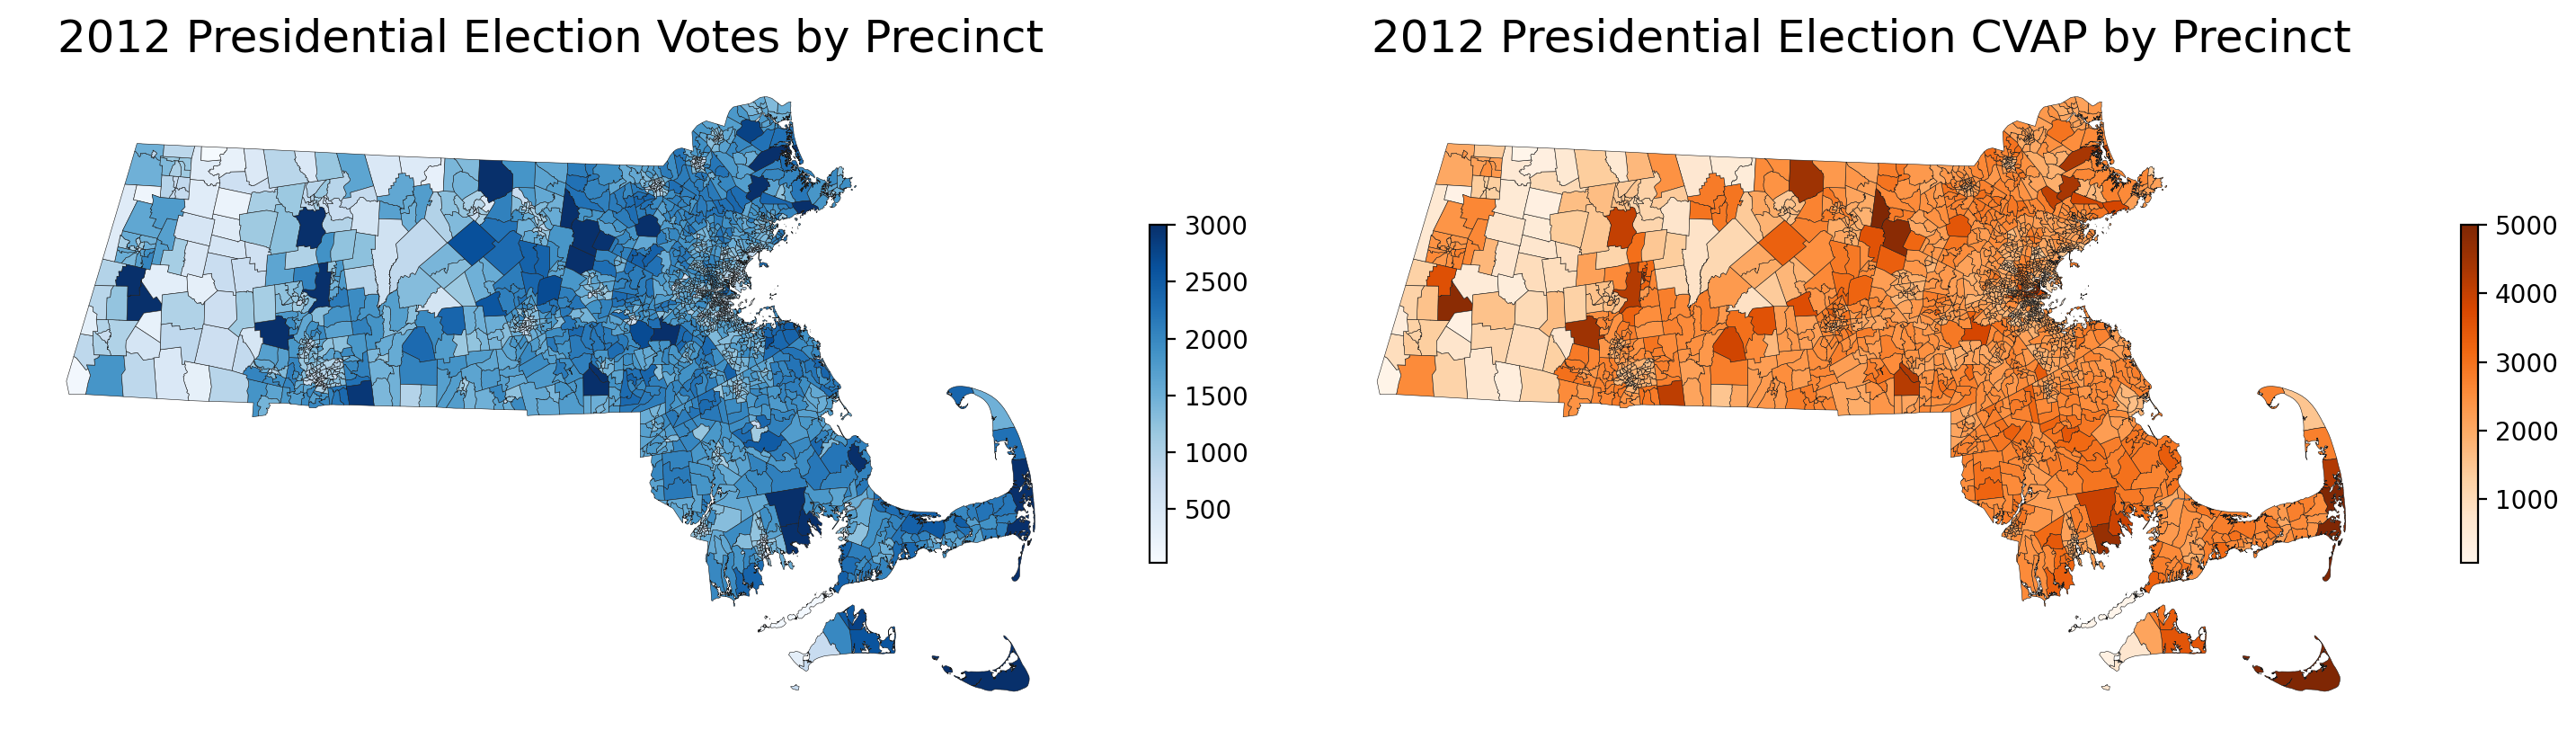

In [56]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].axis('off')
ax[0].set_title("2012 Presidential Election Votes by Precinct", fontsize=18)
ma_ward_precinct_gdf.plot(
    ax=ax[0],
    column="Total Votes",
    vmin=min(ma_ward_precinct_gdf["Total Votes"]),
    vmax=3000,
    edgecolor="0.1",
    linewidth=0.2,
    cmap="Blues",
    legend=True,
    legend_kwds={'shrink': 0.4},
)

ax[1].axis('off')
ax[1].set_title("2012 Presidential Election CVAP by Precinct", fontsize=18)
ma_ward_precinct_gdf.plot(
    ax=ax[1],
    column="CVAP",
    vmin=min(ma_ward_precinct_gdf["CVAP"]),
    vmax=5000,
    edgecolor="0.1",
    linewidth=0.2,
    cmap="Oranges",
    legend=True,
    legend_kwds={'shrink': 0.4},
)
plt.tight_layout()
plt.show()

### DISCUSSION: Ways to prorate

Here's a somewhat different (and arguably better) way to do it....

$$
\text{CVAP}(block\ X) = \frac{\text{CVAP}_{ACS}(tract\ Y)}{\text{VAP}_{ACS}(tract\ Y)}\cdot \text{VAP}_{PL}(block\ X)
$$

with the exception of when $\text{VAP}_{ACS}(tract\ Y) < 20$, in which case

$$
\text{CVAP}(block\ X) = \frac{\text{CVAP}_{ACS}(state\ Z)}{\text{VAP}_{ACS}(state\ Z)}\cdot \text{VAP}_{PL}(block\ X)
$$

This is what the Data and Democracy Lab uses for its CVAP calculation
(see [data-democracy.org/vap-cvap](data-democracy.org/vap-cvap)). In addition to the low-population correction, this formula differs from the previous one in interpretation.

<br>

What does this one mean and what are some reasons you might prefer it?

# Homework 3

**Warmup question:** Which precinct in Massachusetts has the highest turnout (votes as a share of CVAP)?  Would it be possible to get a result over 100%?  Explain.

**Data product:** "MAUP" as a geography problem is the idea that the impression given by geographical data may be very different depending on the mapping units.  One intuitive example is segregation, where areas may look more or less sharply divided depending on the resolution of the map.  Choose a U.S. city and find an area where there's a visible distinction in some census variable with one set of mapping units, but it is greatly reduced with another choice of units.  

**Reading response:** Monmonier tells numerous stories of sloppy mapping, theft by mapping, and fights over mapping. Pick one story and briefly describe whether/how the story involves dueling experts, physical tools, map notation, money, and legal authority.